# Projeto: LogsSQLi

**Disciplina:** Análise de Dados  
**Instituição:** Faculdade Engenheiro Salvador Arena  
**Data:** 12 de Abril de 2026 | **Versão:** 1.0  

---

### Descrição Executiva

Este notebook consolida a etapa de **Modelagem Preditiva (M3)** do projeto **LogsSQLi**, dando continuidade ao pipeline construído nas fases anteriores de **Engenharia de Dados (M1)** e **Análise Exploratória de Dados (M2)**. O foco desta etapa é desenvolver, treinar, comparar e aplicar modelos de **Deep Learning** capazes de identificar padrões de **SQL Injection (SQLi)** em parâmetros extraídos de requisições HTTP observadas em logs do servidor **Nginx**, associados à aplicação vulnerável [OWASP Juice Shop](https://owasp.org/www-project-juice-shop/).

A base utilizada nesta etapa foi derivada do notebook de ETL e EDA, no qual os logs foram estruturados, os parâmetros HTTP foram expandidos, os valores foram decodificados e normalizados, e uma dimensão de payloads SQLi foi consolidada a partir de um dataset de referência. Com base nessas saídas processadas, este notebook organiza duas frentes principais de modelagem: a preparação supervisionada das amostras e o treinamento comparativo de arquiteturas neurais para detecção de SQLi.

A estratégia de modelagem adotada privilegiou a **vetorização textual em nível de caractere**, abordagem especialmente adequada para payloads e parâmetros HTTP que contêm operadores, aspas, comentários, funções SQL, símbolos especiais e variações sintáticas comuns em tentativas de injeção. A partir dessa representação, foram treinados e comparados diferentes modelos neurais baseados em famílias recorrentes, convolucionais e híbridas, incluindo arquiteturas alinhadas à literatura sobre detecção de ataques web, como **CNN**, **BiLSTM** e **CNN + LSTM/BiLSTM**.

Os experimentos mostraram desempenho muito elevado na tarefa de **classificação binária**, permitindo distinguir entradas classificadas como **`SQLi`** e **`Nao_SQLi`**. Entre os modelos avaliados, a arquitetura selecionada como principal foi **Embedding + Conv1D + MaxPooling1D + BiLSTM + Dense**, por combinar extração de padrões locais e sensibilidade à estrutura sequencial dos textos analisados. Esse modelo foi então aplicado à base `df_params`, produzindo probabilidades de risco por parâmetro, classificação binária final e consolidações analíticas por requisição, endpoint e status HTTP.

Também foi conduzido um experimento exploratório de **classificação multirrótulo dos tipos de SQL Injection**. Contudo, com a base atualmente disponível, essa tarefa não apresentou desempenho satisfatório nas métricas mais adequadas ao problema. Por esse motivo, a entrega final deste notebook foi concentrada na **detecção binária de payloads SQLi**, mantendo a classificação por tipo apenas como possibilidade de evolução futura, condicionada à ampliação da base de payloads e à maior diversidade de tráfego benigno e malicioso.

Como resultado, este notebook entrega uma solução funcional, documentada e persistida para **detecção binária de SQL Injection em parâmetros HTTP**, além de estabelecer uma estrutura reutilizável para futuras rodadas de treinamento com bases mais amplas e mais representativas.

---

### Equipe

* **Integrante 1:** Victor Flohr Costa Bicudo Larrubia - 082210026
* **Integrante 2:** Vitor Dié dos Santos Pereira - 082210023
* **Integrante 3:** Beatriz de Sá Silva - 081210011
* **Integrante 4:** Bruno Hector Wüsthofen - 082210013

---

### Stack Tecnológica

* **Linguagem:** Python 3.x
* **Ambiente de desenvolvimento e execução:** Google Colab
* **Armazenamento:** Google Drive
* **Fonte de dados:** bases processadas derivadas de logs HTTP do Nginx e dimensão de payloads SQLi
* **Aplicação de origem do tráfego:** OWASP Juice Shop executado em contêiner
* **Servidor Web:** Nginx
* **Abordagem de modelagem:** classificação textual supervisionada com redes neurais profundas
* **Estratégia de representação:** vetorização em nível de caractere
* **Objetivo final desta etapa:** detecção binária de SQL Injection em parâmetros extraídos dos logs

---

### Bibliotecas Utilizadas

* **pandas:** leitura, manipulação, consolidação e análise tabular das bases utilizadas na modelagem
* **numpy:** operações numéricas, apoio à vetorização e manipulação de arrays
* **ast:** conversão controlada de representações textuais de listas em estruturas Python
* **re:** aplicação de expressões regulares para normalização textual e seleção de padrões benignos/suspeitos
* **json:** persistência de metadados, configuração de experimentos e documentação de artefatos
* **datetime:** padronização temporal dos nomes de arquivos e versionamento dos experimentos
* **pathlib:** manipulação de caminhos e persistência organizada de arquivos no Google Drive
* **tensorflow / keras:** construção, treinamento, avaliação, salvamento e reaplicação dos modelos de Deep Learning
* **TextVectorization:** vetorização textual em nível de caractere para entrada dos modelos neurais
* **scikit-learn:** particionamento treino-validação-teste e cálculo de métricas de desempenho, como F1-score, matriz de confusão e classification report
* **tf.data:** criação de pipelines eficientes de dados para treinamento, validação, teste e inferência
* **matplotlib:** suporte opcional à visualização de resultados, históricos de treino e gráficos comparativos

---

### Estrutura de Diretórios (Drive)

    LogsSQLi/
    └── data/
        ├── raw/   (Dados originais sem modificação)
        └── processed/   (Tabelas Fato e Dimensão prontas para uso)

### 1. Contexto do projeto

### Fluxo do Pipeline Analítico

O projeto **LogsSQLi** está organizado em um fluxo contínuo que integra **Engenharia de Dados (ETL)**, **Análise Exploratória (EDA)** e **Modelagem Preditiva (ML)**. Esse encadeamento garante rastreabilidade entre os dados brutos de tráfego HTTP, as bases processadas e os artefatos finais de classificação.

#### Fluxo do `run_pipeline.sh`

1. converter `logs/access.log` em `data/raw/access_log_structured.csv`;
2. garantir a disponibilidade de `payloads_dataset.csv` em `data/raw`;
3. sincronizar `data/raw` com `gdrive_logsqli:LogsSQLi/data/raw`.

#### Fluxo integrado do projeto

Após a execução do pipeline inicial, o projeto segue as seguintes etapas analíticas:

1. **ETL (M1)**  
   Leitura dos logs estruturados e do dataset de payloads, padronização dos campos, extração de atributos derivados da requisição HTTP, expansão dos parâmetros da query string, decodificação dos valores observados e persistência das bases tratadas em `data/processed`.

2. **EDA (M2)**  
   Análise estatística e exploratória das bases processadas, com avaliação de distribuições, medidas descritivas, correlações, outliers e estratégias iniciais de detecção de SQL Injection por correspondência exata, contenção e heurísticas textuais.

3. **ML (M3)**  
   Construção das bases supervisionadas, vetorização textual em nível de caractere, treinamento e comparação de arquiteturas neurais para detecção binária de SQL Injection, seleção do melhor modelo e aplicação final sobre `df_params`, com geração de alertas por parâmetro, requisição, endpoint e status HTTP.

#### Estrutura lógica das camadas

- **`data/raw`**: arquivos brutos e estruturados de entrada do pipeline;
- **`data/processed`**: bases derivadas, tabelas auxiliares e saídas analíticas produzidas no ETL e na EDA;
- **`data/processed/ml`**: bases de treino, metadados, splits, modelos treinados, métricas e consolidações finais da etapa de Machine Learning.

### 2. Configuração do ambiente

In [69]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import drive
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM
from tensorflow.keras.models import load_model
from sklearn.metrics import f1_score, classification_report, confusion_matrix, hamming_loss, roc_curve, auc
from datetime import datetime
import json
import pandas as pd
import ast
import numpy as np
import re
import tensorflow as tf
import time

MODEL_TIMINGS = {}

def registrar_tempo_modelo(model_name: str, elapsed_seconds: float):
    MODEL_TIMINGS[model_name] = {
        "tempo_segundos": float(elapsed_seconds),
        "tempo_milissegundos": float(elapsed_seconds * 1000.0)
    }

print("Estrutura de controle de tempo inicializada com sucesso.")
print("MODEL_TIMINGS =", MODEL_TIMINGS)

Estrutura de controle de tempo inicializada com sucesso.
MODEL_TIMINGS = {}


### 3. Carregamento e validação das bases de entrada

In [70]:
drive.mount('/content/drive')
base_dir = Path("/content/drive/MyDrive/LogsSQLi/data/processed")

params_path = base_dir / "df_params.csv"
payload_dim_path = base_dir / "df_payload_dim.csv"

if not params_path.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {params_path}")

if not payload_dim_path.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {payload_dim_path}")

df_params = pd.read_csv(params_path)
df_payload_dim = pd.read_csv(payload_dim_path)

print("df_params carregado:", df_params.shape)
print("df_payload_dim carregado:", df_payload_dim.shape)

required_params_cols = {
    "log_id",
    "param_value_decoded",
    "param_value_match_key"
}

required_payload_cols = {
    "payload_match_key",
    "tipo_match_exato"
}

missing_params = required_params_cols - set(df_params.columns)
missing_payload = required_payload_cols - set(df_payload_dim.columns)

if missing_params:
    raise ValueError(f"Colunas ausentes em df_params: {sorted(missing_params)}")

if missing_payload:
    raise ValueError(f"Colunas ausentes em df_payload_dim: {sorted(missing_payload)}")

print("\nValidação estrutural concluída com sucesso.")

print("\nColunas de df_params:")
print(sorted(df_params.columns))

print("\nColunas de df_payload_dim:")
print(sorted(df_payload_dim.columns))

print("\nAmostra de df_params:")
display(df_params.head(3))

print("\nAmostra de df_payload_dim:")
display(df_payload_dim.head(3))

print("\nDistribuição de tipo_match_exato em df_payload_dim:")
display(df_payload_dim["tipo_match_exato"].value_counts(dropna=False).to_frame("qtd"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
df_params carregado: (3627, 19)
df_payload_dim carregado: (177, 6)

Validação estrutural concluída com sucesso.

Colunas de df_params:
['body_bytes_sent', 'has_equals_sign', 'http_method', 'log_id', 'param_name_raw', 'param_position', 'param_raw', 'param_value_decoded', 'param_value_decoded_length', 'param_value_match_key', 'param_value_raw', 'param_value_raw_length', 'param_value_was_changed', 'query_string', 'request_success', 'request_time', 'status', 'time_local', 'url_path']

Colunas de df_payload_dim:
['payload_example', 'payload_match_key', 'qtd_payloads_origem', 'qtd_tipos_distintos', 'tipo_match_exato', 'tipos_encontrados']

Amostra de df_params:


,log_id,time_local,status,request_success,request_time,body_bytes_sent,http_method,url_path,query_string,param_position,param_raw,param_name_raw,param_value_raw,has_equals_sign,param_value_decoded,param_value_match_key,param_value_raw_length,param_value_decoded_length,param_value_was_changed
0,1,25/Feb/2026:18:53:41 +0000,200,1,0.014,517,GET,/rest/products/search,q=test,1,q=test,q,test,1,test,test,4,4,0
1,2,25/Feb/2026:18:53:41 +0000,200,1,0.011,517,GET,/rest/products/search,q=test&SLHJ=1989%20AND%201%3D1%20UNION%20ALL%2...,1,q=test,q,test,1,test,test,4,4,0
2,2,25/Feb/2026:18:53:41 +0000,200,1,0.011,517,GET,/rest/products/search,q=test&SLHJ=1989%20AND%201%3D1%20UNION%20ALL%2...,2,SLHJ=1989%20AND%201%3D1%20UNION%20ALL%20SELECT...,SLHJ,1989%20AND%201%3D1%20UNION%20ALL%20SELECT%201%...,1,"1989 AND 1=1 UNION ALL SELECT 1,NULL,'<script>...","1989 and 1=1 union all select 1,null,'<script>...",258,172,1



Amostra de df_payload_dim:


,payload_match_key,payload_example,qtd_payloads_origem,qtd_tipos_distintos,tipos_encontrados,tipo_match_exato
0,' and '1'='1,' AND '1'='1,40,2,"['Boolean_Based', 'Error_Based']",Ambiguous
1,' and '1'='1' #,' AND '1'='1' #,15,1,['Comment_Based'],Comment_Based
2,' and '1'='1' --,' AND '1'='1' --,15,1,['Comment_Based'],Comment_Based



Distribuição de tipo_match_exato em df_payload_dim:


,qtd
tipo_match_exato,
Comment_Based,20
OOB,15
Stored_Procedure,15
Time_Based,15
WAF_Bypass,15
Second_Order,14
Stacked_Queries,14
Boolean_Based,13
Union_Based,13


### 4. Preparação da base de treino a partir da dimensão de payloads

In [71]:
df_payload_train = df_payload_dim.copy()

# Padronização básica
df_payload_train["payload_match_key"] = df_payload_train["payload_match_key"].fillna("").astype(str).str.strip()
df_payload_train["payload_example"] = df_payload_train["payload_example"].fillna("").astype(str)
df_payload_train["tipo_match_exato"] = df_payload_train["tipo_match_exato"].fillna("").astype(str).str.strip()
df_payload_train["tipos_encontrados"] = df_payload_train["tipos_encontrados"].fillna("[]").astype(str).str.strip()

# Mantém apenas linhas com texto válido para treino
df_payload_train = df_payload_train[df_payload_train["payload_match_key"] != ""].copy()

def parse_tipos_lista(valor):
    if pd.isna(valor):
        return []
    if isinstance(valor, list):
        return [str(v).strip() for v in valor if str(v).strip()]

    s = str(valor).strip()
    if not s or s == "[]":
        return []

    try:
        convertido = ast.literal_eval(s)
        if isinstance(convertido, list):
            return [str(v).strip() for v in convertido if str(v).strip()]
    except Exception:
        pass

    return [s]

# Lista de tipos
df_payload_train["tipos_lista"] = df_payload_train["tipos_encontrados"].apply(parse_tipos_lista)

# Ajuste para casos em que tipos_encontrados esteja vazio, mas tipo_match_exato exista
mask_sem_lista = df_payload_train["tipos_lista"].apply(len).eq(0) & df_payload_train["tipo_match_exato"].ne("")
df_payload_train.loc[mask_sem_lista, "tipos_lista"] = df_payload_train.loc[mask_sem_lista, "tipo_match_exato"].apply(lambda x: [x])

# Alvo binário: aqui todas as amostras são SQLi
df_payload_train["target_sqli_binario"] = 1

# Texto de entrada do modelo
df_payload_train["texto_entrada"] = df_payload_train["payload_match_key"]

# Rótulo textual consolidado
df_payload_train["tipos_alvo"] = df_payload_train["tipos_lista"].apply(
    lambda x: ", ".join(x) if len(x) > 0 else "Unlabeled_SQLi"
)

# Tipos únicos reais
tipos_unicos = sorted(
    {
        tipo
        for sublista in df_payload_train["tipos_lista"]
        for tipo in sublista
        if str(tipo).strip()
    }
)

# Colunas multi-rótulo
for tipo in tipos_unicos:
    df_payload_train[f"tipo__{tipo}"] = df_payload_train["tipos_lista"].apply(lambda x: int(tipo in x))

# Estatísticas auxiliares
df_payload_train["texto_len"] = df_payload_train["texto_entrada"].str.len()

ml_dir = Path("/content/drive/MyDrive/LogsSQLi/data/processed/ml")
ml_dir.mkdir(parents=True, exist_ok=True)

df_payload_train.to_csv(ml_dir / "df_payload_train_supervisionado.csv", index=False)

print("Base de treino criada com sucesso.")
print("Shape df_payload_train:", df_payload_train.shape)
print("Arquivo salvo em:", ml_dir / "df_payload_train_supervisionado.csv")

print("\nQuantidade de tipos distintos:")
print(len(tipos_unicos))
print(tipos_unicos)

print("\nDistribuição de tipos consolidados:")
display(df_payload_train["tipos_alvo"].value_counts().to_frame("qtd"))

print("\nEstatísticas do comprimento do texto:")
display(df_payload_train["texto_len"].describe().to_frame("valor"))

print("\nAmostra da base de treino:")
colunas_preview = [
    "payload_example",
    "payload_match_key",
    "tipo_match_exato",
    "tipos_lista",
    "tipos_alvo",
    "texto_len"
]
display(df_payload_train[colunas_preview].head(10))

Base de treino criada com sucesso.
Shape df_payload_train: (177, 23)
Arquivo salvo em: /content/drive/MyDrive/LogsSQLi/data/processed/ml/df_payload_train_supervisionado.csv

Quantidade de tipos distintos:
12
['Boolean_Based', 'Comment_Based', 'DNS_Exfiltration', 'Error_Based', 'Hybrid', 'OOB', 'Second_Order', 'Stacked_Queries', 'Stored_Procedure', 'Time_Based', 'Union_Based', 'WAF_Bypass']

Distribuição de tipos consolidados:


,qtd
tipos_alvo,
Comment_Based,20
Stored_Procedure,15
OOB,15
Time_Based,15
WAF_Bypass,15
Second_Order,14
Stacked_Queries,14
Boolean_Based,13
Union_Based,13



Estatísticas do comprimento do texto:


,valor
count,177.000000
mean,47.994350
std,26.505895
min,8.000000
25%,27.000000
50%,47.000000
75%,64.000000
max,155.000000



Amostra da base de treino:


,payload_example,payload_match_key,tipo_match_exato,tipos_lista,tipos_alvo,texto_len
0,' AND '1'='1,' and '1'='1,Ambiguous,"[Boolean_Based, Error_Based]","Boolean_Based, Error_Based",12
1,' AND '1'='1' #,' and '1'='1' #,Comment_Based,[Comment_Based],Comment_Based,15
2,' AND '1'='1' --,' and '1'='1' --,Comment_Based,[Comment_Based],Comment_Based,16
3,' AND '1'='1' /*,' and '1'='1' /*,Comment_Based,[Comment_Based],Comment_Based,16
4,' AND '1'='2,' and '1'='2,Boolean_Based,[Boolean_Based],Boolean_Based,12
5,' AND (SELECT 1 FROM dual) IS NOT NULL,' and (select 1 from dual) is not null,Boolean_Based,[Boolean_Based],Boolean_Based,38
6,' AND (SELECT COUNT(*) FROM information_schema...,' and (select count(*) from information_schema...,Boolean_Based,[Boolean_Based],Boolean_Based,82
7,' AND (SELECT COUNT(*) FROM information_schema...,' and (select count(*) from information_schema...,Boolean_Based,[Boolean_Based],Boolean_Based,57
8,' AND (SELECT COUNT(*) FROM users)>0,' and (select count(*) from users)>0,Boolean_Based,[Boolean_Based],Boolean_Based,36
9,"' AND (SELECT EXTRACTVALUE(NULL, CONCAT(0x5c5c...","' and (select extractvalue(null, concat(0x5c5c...",OOB,[OOB],OOB,93


### 5. Reconstrução da base binária com negativos controlados

In [72]:
# =========================================================
# 1) Positivos: payloads SQLi conhecidos
# =========================================================
df_pos_bin = df_payload_train[["texto_entrada", "tipos_alvo"]].copy()
df_pos_bin["texto_entrada"] = df_pos_bin["texto_entrada"].fillna("").astype(str).str.strip().str.lower()
df_pos_bin["target_sqli_binario"] = 1
df_pos_bin["origem"] = "df_payload_dim"

payloads_positivos = set(df_pos_bin["texto_entrada"].tolist())

# =========================================================
# 2) Funções auxiliares para negativos benignos
# =========================================================
regex_caracteres_benignos = re.compile(r"^[a-z0-9][a-z0-9 _\-\.\@:/,]{0,39}$", flags=re.IGNORECASE)

regex_suspeito = re.compile(
    r"(--|/\*|\*/|#|;|'|\"|\(|\)|=|<|>|\\|@@|0x|"
    r"\bunion\b|\bselect\b|\binsert\b|\bupdate\b|\bdelete\b|\bdrop\b|\bexec\b|\bdeclare\b|"
    r"\bcast\b|\bconvert\b|\bconcat\b|\bextractvalue\b|\bupdatexml\b|\bbenchmark\b|\bsleep\b|"
    r"\bwaitfor\b|\bhaving\b|\bbetween\b|\blike\b|\band\b|\bor\b|\bnot\b|\bwhere\b|\bfrom\b|"
    r"\binto\b|\boutfile\b|\binformation_schema\b|\bxp_cmdshell\b|\bload_file\b)",
    flags=re.IGNORECASE
)

def eh_benigno_alta_confianca(texto: str) -> bool:
    t = str(texto).strip().lower()
    if not t:
        return False
    if len(t) > 40:
        return False
    if not regex_caracteres_benignos.fullmatch(t):
        return False
    if regex_suspeito.search(t):
        return False
    if t in payloads_positivos:
        return False
    return True

def normalizar_espacos(texto: str) -> str:
    return re.sub(r"\s+", " ", str(texto).strip().lower())

def gerar_variantes_benignas(sementes, qtd_alvo):
    prefixos = ["", "busca ", "item ", "ref ", "codigo ", "produto ", "cliente "]
    sufixos = ["", " 1", " 2", " 10", "-ok", "_ok", " a", " x", " teste", " consulta"]

    variantes = []
    idx = 0
    limite = max(qtd_alvo * 20, 500)

    while len(variantes) < qtd_alvo * 3 and idx < limite:
        semente = sementes[idx % len(sementes)]
        prefixo = prefixos[idx % len(prefixos)]
        sufixo = sufixos[(idx // len(sementes)) % len(sufixos)]

        candidato = normalizar_espacos(f"{prefixo}{semente}{sufixo}")

        if eh_benigno_alta_confianca(candidato):
            variantes.append(candidato)

        idx += 1

    return variantes

# =========================================================
# 3) Seleção de sementes benignas reais em df_params
# =========================================================
df_params_aux = df_params.copy()
df_params_aux["texto_entrada"] = (
    df_params_aux["param_value_decoded"]
    .fillna("")
    .astype(str)
    .map(normalizar_espacos)
)

sementes_benignas = sorted(
    {
        t for t in df_params_aux["texto_entrada"].tolist()
        if eh_benigno_alta_confianca(t)
    }
)

if len(sementes_benignas) == 0:
    raise ValueError(
        "Nenhuma semente benigna de alta confiança foi encontrada em df_params. "
        "Será necessário rever os critérios de seleção."
    )

# =========================================================
# 4) Geração controlada da classe negativa
# =========================================================
qtd_positivos = len(df_pos_bin)

pool_negativos = set(sementes_benignas)
pool_negativos.update(gerar_variantes_benignas(sementes_benignas, qtd_positivos))

pool_negativos = sorted(
    {
        normalizar_espacos(t)
        for t in pool_negativos
        if eh_benigno_alta_confianca(t)
    }
)

if len(pool_negativos) < qtd_positivos:
    print(
        f"Aviso: foram obtidos {len(pool_negativos)} negativos, "
        f"menos que os {qtd_positivos} positivos."
    )

qtd_negativos_final = min(len(pool_negativos), qtd_positivos)

df_neg_bin = pd.DataFrame({
    "texto_entrada": pool_negativos[:qtd_negativos_final],
    "tipos_alvo": "Benign",
    "target_sqli_binario": 0,
    "origem": "df_params_benigno_controlado"
})

# =========================================================
# 5) Base binária final
# =========================================================
df_train_bin = pd.concat(
    [df_pos_bin[["texto_entrada", "tipos_alvo", "target_sqli_binario", "origem"]], df_neg_bin],
    ignore_index=True
).drop_duplicates(subset=["texto_entrada", "target_sqli_binario"]).copy()

df_train_bin = df_train_bin.sample(frac=1, random_state=42).reset_index(drop=True)

ml_dir = Path("/content/drive/MyDrive/LogsSQLi/data/processed/ml")
ml_dir.mkdir(parents=True, exist_ok=True)

df_train_bin.to_csv(ml_dir / "df_train_binario_v2.csv", index=False)

print("Base binária reconstruída com sucesso.")
print("Shape df_train_bin:", df_train_bin.shape)
print("Arquivo salvo em:", ml_dir / "df_train_binario_v2.csv")

print("\nQuantidade de sementes benignas reais encontradas:")
print(len(sementes_benignas))
print(sementes_benignas[:20])

print("\nDistribuição do alvo binário:")
display(
    df_train_bin["target_sqli_binario"]
    .map({0: "Nao_SQLi", 1: "SQLi"})
    .value_counts()
    .to_frame("qtd")
)

print("\nAmostra dos negativos controlados:")
display(df_neg_bin.head(15))

print("\nAmostra da base binária final:")
display(df_train_bin.head(15))

Aviso: foram obtidos 140 negativos, menos que os 177 positivos.
Base binária reconstruída com sucesso.
Shape df_train_bin: (317, 4)
Arquivo salvo em: /content/drive/MyDrive/LogsSQLi/data/processed/ml/df_train_binario_v2.csv

Quantidade de sementes benignas reais encontradas:
2
['6687', 'test']

Distribuição do alvo binário:


,qtd
target_sqli_binario,
SQLi,177
Nao_SQLi,140



Amostra dos negativos controlados:


,texto_entrada,tipos_alvo,target_sqli_binario,origem
0,6687,Benign,0,df_params_benigno_controlado
1,6687 1,Benign,0,df_params_benigno_controlado
2,6687 10,Benign,0,df_params_benigno_controlado
3,6687 2,Benign,0,df_params_benigno_controlado
4,6687 a,Benign,0,df_params_benigno_controlado
5,6687 consulta,Benign,0,df_params_benigno_controlado
6,6687 teste,Benign,0,df_params_benigno_controlado
7,6687 x,Benign,0,df_params_benigno_controlado
8,6687-ok,Benign,0,df_params_benigno_controlado
9,6687_ok,Benign,0,df_params_benigno_controlado



Amostra da base binária final:


,texto_entrada,tipos_alvo,target_sqli_binario,origem
0,"' union select 1,2 from dual where load_file('...",DNS_Exfiltration,1,df_payload_dim
1,produto test 2,Benign,0,df_params_benigno_controlado
2,"' and 1=if((select database())='test',1,0) --",Comment_Based,1,df_payload_dim
3,item 6687-ok,Benign,0,df_params_benigno_controlado
4,"' and (select extractvalue(null, concat(0x5c5c...",OOB,1,df_payload_dim
5,"' union select null,null,null into outfile '\\...",OOB,1,df_payload_dim
6,'; waitfor delay '0:0:5'--,Time_Based,1,df_payload_dim
7,6687_ok,Benign,0,df_params_benigno_controlado
8,"' or benchmark(5000000,md5('test'))--",Time_Based,1,df_payload_dim
9,'; alter table users add column hacked int;--,Stacked_Queries,1,df_payload_dim


### 6. Particionamento das bases para treinamento, validação e teste

In [73]:
# ==========================================
# 1) Base binária
# ==========================================
df_bin = df_train_bin.copy()

X_bin = df_bin["texto_entrada"].astype(str).values
y_bin = df_bin["target_sqli_binario"].astype(int).values

Xb_train, Xb_temp, yb_train, yb_temp = train_test_split(
    X_bin,
    y_bin,
    test_size=0.30,
    random_state=42,
    stratify=y_bin
)

Xb_val, Xb_test, yb_val, yb_test = train_test_split(
    Xb_temp,
    yb_temp,
    test_size=0.50,
    random_state=42,
    stratify=yb_temp
)

print("=== Base binária ===")
print("Treino:", len(Xb_train))
print("Validação:", len(Xb_val))
print("Teste:", len(Xb_test))

print("\nDistribuição y treino:")
print(pd.Series(yb_train).map({0: "Nao_SQLi", 1: "SQLi"}).value_counts())

print("\nDistribuição y validação:")
print(pd.Series(yb_val).map({0: "Nao_SQLi", 1: "SQLi"}).value_counts())

print("\nDistribuição y teste:")
print(pd.Series(yb_test).map({0: "Nao_SQLi", 1: "SQLi"}).value_counts())

# ==========================================
# 2) Base multiclasses / multirrótulo
# ==========================================
df_tipo = df_payload_train.copy()

X_tipo = df_tipo["texto_entrada"].astype(str).values

colunas_tipo = [c for c in df_tipo.columns if c.startswith("tipo__")]
Y_tipo = df_tipo[colunas_tipo].astype(int).values

Xt_train, Xt_temp, Yt_train, Yt_temp = train_test_split(
    X_tipo,
    Y_tipo,
    test_size=0.30,
    random_state=42
)

Xt_val, Xt_test, Yt_val, Yt_test = train_test_split(
    Xt_temp,
    Yt_temp,
    test_size=0.50,
    random_state=42
)

print("\n=== Base de tipos SQLi ===")
print("Treino:", len(Xt_train))
print("Validação:", len(Xt_val))
print("Teste:", len(Xt_test))

print("\nQuantidade de rótulos de tipo:")
print(len(colunas_tipo))
print(colunas_tipo)

# ==========================================
# 3) Persistência opcional dos splits
# ==========================================
splits_dir = Path("/content/drive/MyDrive/LogsSQLi/data/processed/ml/splits")
splits_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({"texto_entrada": Xb_train, "target_sqli_binario": yb_train}).to_csv(splits_dir / "bin_train.csv", index=False)
pd.DataFrame({"texto_entrada": Xb_val, "target_sqli_binario": yb_val}).to_csv(splits_dir / "bin_val.csv", index=False)
pd.DataFrame({"texto_entrada": Xb_test, "target_sqli_binario": yb_test}).to_csv(splits_dir / "bin_test.csv", index=False)

df_tipo_train = pd.DataFrame({"texto_entrada": Xt_train})
for i, col in enumerate(colunas_tipo):
    df_tipo_train[col] = Yt_train[:, i]

df_tipo_val = pd.DataFrame({"texto_entrada": Xt_val})
for i, col in enumerate(colunas_tipo):
    df_tipo_val[col] = Yt_val[:, i]

df_tipo_test = pd.DataFrame({"texto_entrada": Xt_test})
for i, col in enumerate(colunas_tipo):
    df_tipo_test[col] = Yt_test[:, i]

df_tipo_train.to_csv(splits_dir / "tipo_train.csv", index=False)
df_tipo_val.to_csv(splits_dir / "tipo_val.csv", index=False)
df_tipo_test.to_csv(splits_dir / "tipo_test.csv", index=False)

print("\nSplits salvos em:", splits_dir)

=== Base binária ===
Treino: 221
Validação: 48
Teste: 48

Distribuição y treino:
SQLi        123
Nao_SQLi     98
Name: count, dtype: int64

Distribuição y validação:
SQLi        27
Nao_SQLi    21
Name: count, dtype: int64

Distribuição y teste:
SQLi        27
Nao_SQLi    21
Name: count, dtype: int64

=== Base de tipos SQLi ===
Treino: 123
Validação: 27
Teste: 27

Quantidade de rótulos de tipo:
12
['tipo__Boolean_Based', 'tipo__Comment_Based', 'tipo__DNS_Exfiltration', 'tipo__Error_Based', 'tipo__Hybrid', 'tipo__OOB', 'tipo__Second_Order', 'tipo__Stacked_Queries', 'tipo__Stored_Procedure', 'tipo__Time_Based', 'tipo__Union_Based', 'tipo__WAF_Bypass']

Splits salvos em: /content/drive/MyDrive/LogsSQLi/data/processed/ml/splits


#### 7. Justificativa do pré-processamento adotado

Embora a orientação geral da atividade mencione técnicas como **One-Hot Encoding**, **Label Encoding**, **StandardScaler** e **MinMaxScaler**, a natureza deste problema exigiu uma estratégia de pré-processamento diferente, mais adequada ao tipo de dado analisado.

Neste projeto, a entrada dos modelos não é composta por atributos tabulares convencionais, mas por **sequências textuais curtas**, correspondentes a payloads e parâmetros HTTP potencialmente associados a ataques de SQL Injection. Esses textos contêm operadores, aspas, comentários, funções SQL, caracteres especiais, palavras-chave e padrões sintáticos cuja **ordem dos caracteres** influencia diretamente a identificação do comportamento malicioso. Por esse motivo, o pré-processamento adotado foi baseado em **vetorização textual em nível de caractere**, utilizando a camada `TextVectorization`.

Essa escolha substitui, de forma mais apropriada, o uso de One-Hot Encoding ou Label Encoding tradicionais. Em bases tabulares, essas técnicas são úteis para representar categorias discretas, como valores nominais ou rótulos de colunas. Contudo, neste caso, aplicá-las diretamente aos textos completos dos payloads resultaria em perda da estrutura sequencial e baixa capacidade de generalização sobre padrões sintáticos relevantes para SQL Injection.

Da mesma forma, o uso de **StandardScaler** ou **MinMaxScaler** não foi adotado como etapa principal de transformação, pois os modelos neurais implementados receberam como entrada sequências tokenizadas em nível de caractere, e não variáveis numéricas contínuas independentes. O escalonamento clássico é mais indicado para atributos numéricos tabulares, especialmente em algoritmos sensíveis à escala, como KNN ou redes neurais sobre vetores numéricos densos. Neste notebook, a própria vetorização textual e a camada de embedding assumem o papel de representação numérica aprendida.

Portanto, a opção por `TextVectorization` com representação em nível de caractere foi tecnicamente mais coerente com o problema estudado, com a estrutura dos dados disponíveis e com o objetivo central do projeto, que é detectar padrões textuais de SQL Injection em parâmetros extraídos de logs HTTP.

### 8. Vetorização textual em nível de caractere

In [74]:
# =========================================================
# 1) Conjuntos de treino em texto
# =========================================================
Xb_train_series = pd.Series(Xb_train).fillna("").astype(str).str.lower().str.strip()
Xt_train_series = pd.Series(Xt_train).fillna("").astype(str).str.lower().str.strip()

# Base textual conjunta para adaptação do vocabulário
textos_train_adapt = pd.concat([Xb_train_series, Xt_train_series], ignore_index=True).drop_duplicates()

# =========================================================
# 2) Estatísticas de comprimento para definir max_len
# =========================================================
comprimentos = textos_train_adapt.str.len()

max_len_p95 = int(np.ceil(comprimentos.quantile(0.95)))
max_len_p99 = int(np.ceil(comprimentos.quantile(0.99)))
max_len_max = int(comprimentos.max())

# escolha conservadora e estável
max_len = min(max(64, max_len_p95), 160)

print("Quantidade de textos usados para adaptar o vocabulário:", len(textos_train_adapt))
print("Comprimento mínimo:", int(comprimentos.min()))
print("Comprimento mediano:", int(comprimentos.median()))
print("Comprimento p95:", max_len_p95)
print("Comprimento p99:", max_len_p99)
print("Comprimento máximo:", max_len_max)
print("max_len definido para vetorização:", max_len)

# =========================================================
# 3) Vetorizador em nível de caractere
# =========================================================
vectorizer_char = TextVectorization(
    standardize=None,
    split="character",
    output_mode="int",
    output_sequence_length=max_len
)

vectorizer_char.adapt(textos_train_adapt.values)

vocabulario = vectorizer_char.get_vocabulary()
vocab_size = len(vocabulario)

print("\nTamanho do vocabulário:", vocab_size)
print("Primeiros 40 tokens do vocabulário:")
print(vocabulario[:40])

# =========================================================
# 4) Teste rápido da vetorização
# =========================================================
amostras_teste = tf.constant([
    "test",
    "' or '1'='1' --",
    "sleep(5)",
    "produto 6687"
])

amostras_vetorizadas = vectorizer_char(amostras_teste)

print("\nShape das amostras vetorizadas:", amostras_vetorizadas.shape)
print("\nPrimeira amostra vetorizada:")
print(amostras_vetorizadas[0].numpy())

# =========================================================
# 5) Persistência dos metadados
# =========================================================
ml_dir = Path("/content/drive/MyDrive/LogsSQLi/data/processed/ml")
ml_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "token": vocabulario
}).to_csv(ml_dir / "char_vocabulary.csv", index=False)

pd.DataFrame([{
    "max_len": max_len,
    "vocab_size": vocab_size,
    "qtd_textos_adapt": len(textos_train_adapt),
    "len_min": int(comprimentos.min()),
    "len_median": int(comprimentos.median()),
    "len_p95": max_len_p95,
    "len_p99": max_len_p99,
    "len_max": max_len_max
}]).to_csv(ml_dir / "char_vectorizer_metadata.csv", index=False)

print("\nArquivos salvos:")
print("-", ml_dir / "char_vocabulary.csv")
print("-", ml_dir / "char_vectorizer_metadata.csv")

Quantidade de textos usados para adaptar o vocabulário: 257
Comprimento mínimo: 4
Comprimento mediano: 22
Comprimento p95: 82
Comprimento p99: 114
Comprimento máximo: 155
max_len definido para vetorização: 82

Tamanho do vocabulário: 58
Primeiros 40 tokens do vocabulário:
['', '[UNK]', np.str_(' '), np.str_('e'), np.str_('t'), np.str_('s'), np.str_('a'), np.str_("'"), np.str_('o'), np.str_('n'), np.str_('r'), np.str_('c'), np.str_('l'), np.str_('-'), np.str_('i'), np.str_('u'), np.str_('d'), np.str_('m'), np.str_(')'), np.str_('('), np.str_('1'), np.str_(','), np.str_('p'), np.str_('6'), np.str_('f'), np.str_(';'), np.str_('_'), np.str_('h'), np.str_('.'), np.str_('k'), np.str_('\\'), np.str_('='), np.str_('b'), np.str_('x'), np.str_('0'), np.str_('w'), np.str_('g'), np.str_('8'), np.str_('7'), np.str_('v')]

Shape das amostras vetorizadas: (4, 82)

Primeira amostra vetorizada:
[4 3 5 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

### 9. Preparação dos pipelines de dados para treinamento

In [75]:
BATCH_SIZE = 32
SEED = 42

# =========================================================
# 1) Base binária
# =========================================================
Xb_train_tf = tf.constant(pd.Series(Xb_train).fillna("").astype(str).str.lower().str.strip().values)
Xb_val_tf   = tf.constant(pd.Series(Xb_val).fillna("").astype(str).str.lower().str.strip().values)
Xb_test_tf  = tf.constant(pd.Series(Xb_test).fillna("").astype(str).str.lower().str.strip().values)

yb_train_tf = tf.constant(yb_train, dtype=tf.float32)
yb_val_tf   = tf.constant(yb_val, dtype=tf.float32)
yb_test_tf  = tf.constant(yb_test, dtype=tf.float32)

ds_bin_train = tf.data.Dataset.from_tensor_slices((Xb_train_tf, yb_train_tf))
ds_bin_val   = tf.data.Dataset.from_tensor_slices((Xb_val_tf, yb_val_tf))
ds_bin_test  = tf.data.Dataset.from_tensor_slices((Xb_test_tf, yb_test_tf))

ds_bin_train = ds_bin_train.shuffle(buffer_size=len(Xb_train_tf), seed=SEED, reshuffle_each_iteration=True).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_bin_val   = ds_bin_val.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_bin_test  = ds_bin_test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# =========================================================
# 2) Base multirrótulo de tipos
# =========================================================
Xt_train_tf = tf.constant(pd.Series(Xt_train).fillna("").astype(str).str.lower().str.strip().values)
Xt_val_tf   = tf.constant(pd.Series(Xt_val).fillna("").astype(str).str.lower().str.strip().values)
Xt_test_tf  = tf.constant(pd.Series(Xt_test).fillna("").astype(str).str.lower().str.strip().values)

Yt_train_tf = tf.constant(Yt_train, dtype=tf.float32)
Yt_val_tf   = tf.constant(Yt_val, dtype=tf.float32)
Yt_test_tf  = tf.constant(Yt_test, dtype=tf.float32)

ds_tipo_train = tf.data.Dataset.from_tensor_slices((Xt_train_tf, Yt_train_tf))
ds_tipo_val   = tf.data.Dataset.from_tensor_slices((Xt_val_tf, Yt_val_tf))
ds_tipo_test  = tf.data.Dataset.from_tensor_slices((Xt_test_tf, Yt_test_tf))

ds_tipo_train = ds_tipo_train.shuffle(buffer_size=len(Xt_train_tf), seed=SEED, reshuffle_each_iteration=True).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_tipo_val   = ds_tipo_val.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_tipo_test  = ds_tipo_test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# =========================================================
# 3) Inspeção rápida dos lotes
# =========================================================
xb_batch, yb_batch = next(iter(ds_bin_train))
xt_batch, yt_batch = next(iter(ds_tipo_train))

print("=== Dataset binário ===")
print("Batch de textos:", xb_batch.shape)
print("Batch de rótulos:", yb_batch.shape)
print("Exemplo de texto:", xb_batch[0].numpy().decode("utf-8"))
print("Exemplo de rótulo:", yb_batch[0].numpy())

print("\n=== Dataset multirrótulo ===")
print("Batch de textos:", xt_batch.shape)
print("Batch de rótulos:", yt_batch.shape)
print("Exemplo de texto:", xt_batch[0].numpy().decode("utf-8"))
print("Exemplo de vetor de rótulos:", yt_batch[0].numpy())

print("\nQuantidade de batches:")
print("ds_bin_train:", tf.data.experimental.cardinality(ds_bin_train).numpy())
print("ds_bin_val:", tf.data.experimental.cardinality(ds_bin_val).numpy())
print("ds_bin_test:", tf.data.experimental.cardinality(ds_bin_test).numpy())
print("ds_tipo_train:", tf.data.experimental.cardinality(ds_tipo_train).numpy())
print("ds_tipo_val:", tf.data.experimental.cardinality(ds_tipo_val).numpy())
print("ds_tipo_test:", tf.data.experimental.cardinality(ds_tipo_test).numpy())

=== Dataset binário ===
Batch de textos: (32,)
Batch de rótulos: (32,)
Exemplo de texto: '; exec sp_executesql n'select * from users where id = 1'--
Exemplo de rótulo: 1.0

=== Dataset multirrótulo ===
Batch de textos: (32,)
Batch de rótulos: (32, 12)
Exemplo de texto: '; exec sp_makewebtask 'c:\inetpub\wwwroot\shell.asp', 'select * from users'--
Exemplo de vetor de rótulos: [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

Quantidade de batches:
ds_bin_train: 7
ds_bin_val: 2
ds_bin_test: 2
ds_tipo_train: 4
ds_tipo_val: 1
ds_tipo_test: 1


### 10. Treinamento do modelo binário de referência

In [88]:
# @title
# =========================================================
# 1) Callbacks
# =========================================================
callbacks_bin_baseline = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

# =========================================================
# 2) Modelo binário baseline
# =========================================================
tf.keras.backend.clear_session()

model_bin_baseline = Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string, name="texto"),
    vectorizer_char,
    Embedding(
        input_dim=vocab_size,
        output_dim=32
    ),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(1, activation="sigmoid")
], name="baseline_binario")

model_bin_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print(model_bin_baseline.summary())

# =========================================================
# 3) Treinamento com medição de tempo
# =========================================================
start_time = time.perf_counter()

history_bin_baseline = model_bin_baseline.fit(
    ds_bin_train,
    validation_data=ds_bin_val,
    epochs=20,
    callbacks=callbacks_bin_baseline,
    verbose=1
)

elapsed_time = time.perf_counter() - start_time
registrar_tempo_modelo("baseline_binario", elapsed_time)

print(f"\nTempo de treinamento (s): {elapsed_time:.4f}")
print(f"Tempo de treinamento (ms): {elapsed_time * 1000:.2f}")

# =========================================================
# 4) Avaliação no conjunto de teste
# =========================================================
resultados_bin_baseline = model_bin_baseline.evaluate(
    ds_bin_test,
    verbose=0,
    return_dict=True
)

yb_proba_baseline = model_bin_baseline.predict(ds_bin_test, verbose=0).ravel()
yb_pred_baseline = (yb_proba_baseline >= 0.5).astype(int)

f1_baseline = f1_score(yb_test, yb_pred_baseline, zero_division=0)
cm_baseline = confusion_matrix(yb_test, yb_pred_baseline)
report_baseline = classification_report(
    yb_test,
    yb_pred_baseline,
    target_names=["Nao_SQLi", "SQLi"],
    output_dict=True,
    zero_division=0
)

resultados_bin_baseline["f1"] = float(f1_baseline)
resultados_bin_baseline["tempo_segundos"] = float(elapsed_time)
resultados_bin_baseline["tempo_milissegundos"] = float(elapsed_time * 1000.0)

print("\n=== Resultados no teste - Modelo Binário Baseline ===")
for k, v in resultados_bin_baseline.items():
    if isinstance(v, (int, float, np.floating)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nMatriz de confusão:")
print(cm_baseline)

print("\nClassification report:")
display(pd.DataFrame(report_baseline).T)

# =========================================================
# 5) Salvamento padronizado no diretório de experiments
# =========================================================
artifacts_bin_baseline = save_experiment_artifacts(
    model=model_bin_baseline,
    history=history_bin_baseline,
    metrics_dict=resultados_bin_baseline,
    model_name="baseline_binario",
    extra_metadata={
        "task": "binary_detection",
        "architecture": "Embedding + GlobalMaxPooling1D + Dense",
        "output_activation": "sigmoid",
        "epochs_trained": len(history_bin_baseline.history["loss"])
    }
)

prefix_baseline = build_experiment_prefix("baseline_binario")

pd.DataFrame(cm_baseline, index=["real_0", "real_1"], columns=["pred_0", "pred_1"]).to_csv(
    EXPERIMENTS_DIR / f"{prefix_baseline}-confusion-matrix.csv"
)

pd.DataFrame(report_baseline).T.to_csv(
    EXPERIMENTS_DIR / f"{prefix_baseline}-classification-report.csv"
)

pd.DataFrame({
    "y_true": yb_test,
    "y_pred": yb_pred_baseline,
    "y_proba": yb_proba_baseline
}).to_csv(
    EXPERIMENTS_DIR / f"{prefix_baseline}-predictions-test.csv",
    index=False
)

print("\nArquivos salvos:")
for k, v in artifacts_bin_baseline.items():
    print(f"- {k}: {v}")

print(f"- confusion_matrix: {EXPERIMENTS_DIR / f'{prefix_baseline}-confusion-matrix.csv'}")
print(f"- classification_report: {EXPERIMENTS_DIR / f'{prefix_baseline}-classification-report.csv'}")
print(f"- predictions_test: {EXPERIMENTS_DIR / f'{prefix_baseline}-predictions-test.csv'}")

print("\nMODEL_TIMINGS atualizado:")
print(MODEL_TIMINGS)

Model: "baseline_binario"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 82)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 82, 32)         │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.5928 - auc: 0.6230 - loss: 0.6905 - precision: 0.6602 - recall: 0.5528 - val_accuracy: 0.7708 - val_auc: 0.9506 - val_loss: 0.6823 - val_precision: 0.7105 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7466 - auc: 0.8836 - loss: 0.6770 - precision: 0.6893 - recall: 0.9919 - val_accuracy: 0.7083 - val_auc: 0.9982 - val_loss: 0.6693 - val_precision: 0.6585 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7330 - auc: 0.9555 - loss: 0.6612 - precision: 0.6758 - recall: 1.0000 - val_accuracy: 0.7292 - val_auc: 1.0000 - val_loss: 0.6532 - val_precision: 0.6750 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7828 - auc: 0.9905 - loss: 0.6401 - precision: 0.7193 - recall: 1.0000 - val_accuracy: 0.7500 - val_auc: 1.0000 - val_loss: 0.6323 - val_precis

,precision,recall,f1-score,support
Nao_SQLi,1.0,1.0,1.0,21.0
SQLi,1.0,1.0,1.0,27.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,48.0
weighted avg,1.0,1.0,1.0,48.0



Arquivos salvos:
- model_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-baseline_binario.keras
- history_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-baseline_binario-history.csv
- metrics_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-baseline_binario-metrics-test.csv
- metadata_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-baseline_binario-metadata.json
- confusion_matrix: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-baseline_binario-confusion-matrix.csv
- classification_report: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-baseline_binario-classification-report.csv
- predictions_test: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-baseline_binario-predictions-test.csv

MODEL_TIMINGS atualizado:
{'baseline_binario': {'tempo_segundos': 6.413800779000667, 'tempo_milissegundos'

### 11. Padronização dos experimentos e salvamento dos artefatos

In [77]:
# @title
EXPERIMENT_DATE = datetime.now().strftime("%d-%m-%Y")
EXPERIMENTS_DIR = Path("/content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments")
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)

print("Data dos experimentos:", EXPERIMENT_DATE)
print("Diretório base:", EXPERIMENTS_DIR)

def build_experiment_prefix(model_name: str) -> str:
    model_name = str(model_name).strip().lower().replace(" ", "_")
    return f"{EXPERIMENT_DATE}-{model_name}"

def save_experiment_artifacts(
    model,
    history,
    metrics_dict,
    model_name: str,
    extra_metadata: dict | None = None
):
    prefix = build_experiment_prefix(model_name)
    model_path = EXPERIMENTS_DIR / f"{prefix}.keras"
    history_path = EXPERIMENTS_DIR / f"{prefix}-history.csv"
    metrics_path = EXPERIMENTS_DIR / f"{prefix}-metrics-test.csv"
    metadata_path = EXPERIMENTS_DIR / f"{prefix}-metadata.json"

    model.save(model_path)

    if history is not None:
        pd.DataFrame(history.history).to_csv(history_path, index=False)

    pd.DataFrame([metrics_dict]).to_csv(metrics_path, index=False)

    metadata = {
        "experiment_date": EXPERIMENT_DATE,
        "model_name": model_name,
        "model_file": model_path.name,
        "history_file": history_path.name,
        "metrics_file": metrics_path.name,
        "max_len": int(max_len),
        "vocab_size": int(vocab_size),
        "batch_size": int(BATCH_SIZE),
    }

    if extra_metadata:
        metadata.update(extra_metadata)

    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    return {
        "model_path": str(model_path),
        "history_path": str(history_path),
        "metrics_path": str(metrics_path),
        "metadata_path": str(metadata_path),
    }

# teste rápido da nomenclatura
print("\nExemplos de prefixo:")
print(build_experiment_prefix("baseline_binario"))
print(build_experiment_prefix("conv1d_bilstm_binario"))
print(build_experiment_prefix("bilstm_multirrótulo"))

Data dos experimentos: 12-04-2026
Diretório base: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments

Exemplos de prefixo:
12-04-2026-baseline_binario
12-04-2026-conv1d_bilstm_binario
12-04-2026-bilstm_multirrótulo


### 12. Treinamento do modelo binário principal com Embedding, Conv1D e BiLSTM

In [91]:
# @title
# =========================================================
# 1) Callbacks
# =========================================================
callbacks_conv1d_bilstm_bin = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

# =========================================================
# 2) Modelo principal binário
# =========================================================
tf.keras.backend.clear_session()

model_conv1d_bilstm_bin = Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string, name="texto"),
    vectorizer_char,
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),
    Conv1D(
        filters=128,
        kernel_size=5,
        padding="same",
        activation="relu"
    ),
    MaxPooling1D(pool_size=2),
    Bidirectional(
        LSTM(64, dropout=0.2, recurrent_dropout=0.0)
    ),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(1, activation="sigmoid")
], name="conv1d_bilstm_binario")

model_conv1d_bilstm_bin.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print(model_conv1d_bilstm_bin.summary())

# =========================================================
# 3) Treinamento com medição de tempo
# =========================================================
start_time = time.perf_counter()

history_conv1d_bilstm_bin = model_conv1d_bilstm_bin.fit(
    ds_bin_train,
    validation_data=ds_bin_val,
    epochs=25,
    callbacks=callbacks_conv1d_bilstm_bin,
    verbose=1
)

elapsed_time = time.perf_counter() - start_time
registrar_tempo_modelo("conv1d_bilstm_binario", elapsed_time)

print(f"\nTempo de treinamento (s): {elapsed_time:.4f}")
print(f"Tempo de treinamento (ms): {elapsed_time * 1000:.2f}")

# =========================================================
# 4) Avaliação no teste
# =========================================================
resultados_conv1d_bilstm_bin = model_conv1d_bilstm_bin.evaluate(
    ds_bin_test,
    verbose=0,
    return_dict=True
)

yb_proba_conv1d_bilstm = model_conv1d_bilstm_bin.predict(ds_bin_test, verbose=0).ravel()
yb_pred_conv1d_bilstm = (yb_proba_conv1d_bilstm >= 0.5).astype(int)

f1_bin = f1_score(yb_test, yb_pred_conv1d_bilstm, zero_division=0)
cm_bin = confusion_matrix(yb_test, yb_pred_conv1d_bilstm)
report_bin = classification_report(
    yb_test,
    yb_pred_conv1d_bilstm,
    target_names=["Nao_SQLi", "SQLi"],
    output_dict=True,
    zero_division=0
)

resultados_conv1d_bilstm_bin["f1"] = float(f1_bin)
resultados_conv1d_bilstm_bin["tempo_segundos"] = float(elapsed_time)
resultados_conv1d_bilstm_bin["tempo_milissegundos"] = float(elapsed_time * 1000.0)

print("\n=== Resultados no teste - Conv1D + BiLSTM Binário ===")
for k, v in resultados_conv1d_bilstm_bin.items():
    if isinstance(v, (int, float, np.floating)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nMatriz de confusão:")
print(cm_bin)

print("\nClassification report:")
display(pd.DataFrame(report_bin).T)

# =========================================================
# 5) Salvamento padronizado
# =========================================================
artifacts_conv1d_bilstm_bin = save_experiment_artifacts(
    model=model_conv1d_bilstm_bin,
    history=history_conv1d_bilstm_bin,
    metrics_dict=resultados_conv1d_bilstm_bin,
    model_name="conv1d_bilstm_binario",
    extra_metadata={
        "task": "binary_detection",
        "architecture": "Embedding + Conv1D + MaxPooling1D + BiLSTM + Dense",
        "output_activation": "sigmoid",
        "epochs_trained": len(history_conv1d_bilstm_bin.history["loss"])
    }
)

prefix_conv1d_bilstm_bin = build_experiment_prefix("conv1d_bilstm_binario")

pd.DataFrame(cm_bin, index=["real_0", "real_1"], columns=["pred_0", "pred_1"]).to_csv(
    EXPERIMENTS_DIR / f"{prefix_conv1d_bilstm_bin}-confusion-matrix.csv"
)

pd.DataFrame(report_bin).T.to_csv(
    EXPERIMENTS_DIR / f"{prefix_conv1d_bilstm_bin}-classification-report.csv"
)

pd.DataFrame({
    "y_true": yb_test,
    "y_pred": yb_pred_conv1d_bilstm,
    "y_proba": yb_proba_conv1d_bilstm
}).to_csv(
    EXPERIMENTS_DIR / f"{prefix_conv1d_bilstm_bin}-predictions-test.csv",
    index=False
)

print("\nArquivos salvos:")
for k, v in artifacts_conv1d_bilstm_bin.items():
    print(f"- {k}: {v}")

print(f"- confusion_matrix: {EXPERIMENTS_DIR / f'{prefix_conv1d_bilstm_bin}-confusion-matrix.csv'}")
print(f"- classification_report: {EXPERIMENTS_DIR / f'{prefix_conv1d_bilstm_bin}-classification-report.csv'}")
print(f"- predictions_test: {EXPERIMENTS_DIR / f'{prefix_conv1d_bilstm_bin}-predictions-test.csv'}")

print("\nMODEL_TIMINGS atualizado:")
print(MODEL_TIMINGS)

Model: "conv1d_bilstm_binario"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 82)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 82, 64)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 82, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 41, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,937 (593.50 KB)

 Trainable params: 151,937 (593.50 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.5656 - auc: 0.6958 - loss: 0.6814 - precision: 0.5714 - recall: 0.8780 - val_accuracy: 0.5625 - val_auc: 0.9991 - val_loss: 0.6587 - val_precision: 0.5625 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7421 - auc: 0.9472 - loss: 0.6113 - precision: 0.6941 - recall: 0.9593 - val_accuracy: 0.9375 - val_auc: 0.9921 - val_loss: 0.4806 - val_precision: 1.0000 - val_recall: 0.8889 - learning_rate: 0.0010
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9548 - auc: 0.9915 - loss: 0.3262 - precision: 0.9829 - recall: 0.9350 - val_accuracy: 0.9583 - val_auc: 0.9921 - val_loss: 0.1619 - val_precision: 1.0000 - val_recall: 0.9259 - learning_rate: 0.0010
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9683 - auc: 0.9930 - loss: 0.1031 - precision: 0.9915 - recall: 0.9512 - val_accuracy: 0.9583 - val_auc: 1.0000 - val_loss: 0.0600 - val_preci

,precision,recall,f1-score,support
Nao_SQLi,1.0,1.0,1.0,21.0
SQLi,1.0,1.0,1.0,27.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,48.0
weighted avg,1.0,1.0,1.0,48.0



Arquivos salvos:
- model_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-conv1d_bilstm_binario.keras
- history_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-conv1d_bilstm_binario-history.csv
- metrics_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-conv1d_bilstm_binario-metrics-test.csv
- metadata_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-conv1d_bilstm_binario-metadata.json
- confusion_matrix: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-conv1d_bilstm_binario-confusion-matrix.csv
- classification_report: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-conv1d_bilstm_binario-classification-report.csv
- predictions_test: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-conv1d_bilstm_binario-predictions-test.csv

MODEL_TIMINGS atualizado:
{'baseline_binario': {'tempo_segundos': 5.961

### 13. Treinamento do modelo binário comparativo com Embedding e BiLSTM

In [92]:
# @title
# =========================================================
# 1) Callbacks
# =========================================================
callbacks_bilstm_bin = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

# =========================================================
# 2) Modelo BiLSTM binário
# =========================================================
tf.keras.backend.clear_session()

model_bilstm_bin = Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string, name="texto"),
    vectorizer_char,
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),
    Bidirectional(
        LSTM(64, dropout=0.2, recurrent_dropout=0.0)
    ),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(1, activation="sigmoid")
], name="bilstm_binario")

model_bilstm_bin.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print(model_bilstm_bin.summary())

# =========================================================
# 3) Treinamento com medição de tempo
# =========================================================
start_time = time.perf_counter()

history_bilstm_bin = model_bilstm_bin.fit(
    ds_bin_train,
    validation_data=ds_bin_val,
    epochs=25,
    callbacks=callbacks_bilstm_bin,
    verbose=1
)

elapsed_time = time.perf_counter() - start_time
registrar_tempo_modelo("bilstm_binario", elapsed_time)

print(f"\nTempo de treinamento (s): {elapsed_time:.4f}")
print(f"Tempo de treinamento (ms): {elapsed_time * 1000:.2f}")

# =========================================================
# 4) Avaliação no teste
# =========================================================
resultados_bilstm_bin = model_bilstm_bin.evaluate(
    ds_bin_test,
    verbose=0,
    return_dict=True
)

yb_proba_bilstm = model_bilstm_bin.predict(ds_bin_test, verbose=0).ravel()
yb_pred_bilstm = (yb_proba_bilstm >= 0.5).astype(int)

f1_bilstm = f1_score(yb_test, yb_pred_bilstm, zero_division=0)
cm_bilstm = confusion_matrix(yb_test, yb_pred_bilstm)
report_bilstm = classification_report(
    yb_test,
    yb_pred_bilstm,
    target_names=["Nao_SQLi", "SQLi"],
    output_dict=True,
    zero_division=0
)

resultados_bilstm_bin["f1"] = float(f1_bilstm)
resultados_bilstm_bin["tempo_segundos"] = float(elapsed_time)
resultados_bilstm_bin["tempo_milissegundos"] = float(elapsed_time * 1000.0)

print("\n=== Resultados no teste - BiLSTM Binário ===")
for k, v in resultados_bilstm_bin.items():
    if isinstance(v, (int, float, np.floating)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nMatriz de confusão:")
print(cm_bilstm)

print("\nClassification report:")
display(pd.DataFrame(report_bilstm).T)

# =========================================================
# 5) Salvamento padronizado
# =========================================================
artifacts_bilstm_bin = save_experiment_artifacts(
    model=model_bilstm_bin,
    history=history_bilstm_bin,
    metrics_dict=resultados_bilstm_bin,
    model_name="bilstm_binario",
    extra_metadata={
        "task": "binary_detection",
        "architecture": "Embedding + BiLSTM + Dense",
        "output_activation": "sigmoid",
        "epochs_trained": len(history_bilstm_bin.history["loss"])
    }
)

prefix_bilstm_bin = build_experiment_prefix("bilstm_binario")

pd.DataFrame(cm_bilstm, index=["real_0", "real_1"], columns=["pred_0", "pred_1"]).to_csv(
    EXPERIMENTS_DIR / f"{prefix_bilstm_bin}-confusion-matrix.csv"
)

pd.DataFrame(report_bilstm).T.to_csv(
    EXPERIMENTS_DIR / f"{prefix_bilstm_bin}-classification-report.csv"
)

pd.DataFrame({
    "y_true": yb_test,
    "y_pred": yb_pred_bilstm,
    "y_proba": yb_proba_bilstm
}).to_csv(
    EXPERIMENTS_DIR / f"{prefix_bilstm_bin}-predictions-test.csv",
    index=False
)

print("\nArquivos salvos:")
for k, v in artifacts_bilstm_bin.items():
    print(f"- {k}: {v}")

print(f"- confusion_matrix: {EXPERIMENTS_DIR / f'{prefix_bilstm_bin}-confusion-matrix.csv'}")
print(f"- classification_report: {EXPERIMENTS_DIR / f'{prefix_bilstm_bin}-classification-report.csv'}")
print(f"- predictions_test: {EXPERIMENTS_DIR / f'{prefix_bilstm_bin}-predictions-test.csv'}")

print("\nMODEL_TIMINGS atualizado:")
print(MODEL_TIMINGS)

Model: "bilstm_binario"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 82)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 82, 64)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,081 (305.00 KB)

 Trainable params: 78,081 (305.00 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 367ms/step - accuracy: 0.6425 - auc: 0.7937 - loss: 0.6763 - precision: 0.6158 - recall: 0.9512 - val_accuracy: 0.6250 - val_auc: 1.0000 - val_loss: 0.6441 - val_precision: 0.6000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8688 - auc: 0.9989 - loss: 0.5918 - precision: 0.8092 - recall: 1.0000 - val_accuracy: 0.9792 - val_auc: 1.0000 - val_loss: 0.4775 - val_precision: 1.0000 - val_recall: 0.9630 - learning_rate: 0.0010
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9457 - auc: 0.9960 - loss: 0.3641 - precision: 0.9912 - recall: 0.9106 - val_accuracy: 0.9792 - val_auc: 1.0000 - val_loss: 0.1927 - val_precision: 1.0000 - val_recall: 0.9630 - learning_rate: 0.0010
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9593 - auc: 0.9973 - loss: 0.1515 - precision: 0.9831 - recall: 0.9431 - val_accuracy: 0.9792 - val_auc: 1.0000 - val_loss: 0.0640 - val_prec

,precision,recall,f1-score,support
Nao_SQLi,1.0,1.0,1.0,21.0
SQLi,1.0,1.0,1.0,27.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,48.0
weighted avg,1.0,1.0,1.0,48.0



Arquivos salvos:
- model_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-bilstm_binario.keras
- history_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-bilstm_binario-history.csv
- metrics_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-bilstm_binario-metrics-test.csv
- metadata_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-bilstm_binario-metadata.json
- confusion_matrix: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-bilstm_binario-confusion-matrix.csv
- classification_report: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-bilstm_binario-classification-report.csv
- predictions_test: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-bilstm_binario-predictions-test.csv

MODEL_TIMINGS atualizado:
{'baseline_binario': {'tempo_segundos': 5.961806493998665, 'tempo_milissegundos': 5961.8064939

### 14. Treinamento do modelo binário comparativo com Embedding e CNN

In [93]:
# @title
# =========================================================
# 1) Callbacks
# =========================================================
callbacks_cnn_bin = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

# =========================================================
# 2) Modelo CNN binário
# =========================================================
tf.keras.backend.clear_session()

model_cnn_bin = Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string, name="texto"),
    vectorizer_char,
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),
    Conv1D(
        filters=128,
        kernel_size=5,
        padding="same",
        activation="relu"
    ),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(1, activation="sigmoid")
], name="cnn_binario")

model_cnn_bin.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print(model_cnn_bin.summary())

# =========================================================
# 3) Treinamento com medição de tempo
# =========================================================
start_time = time.perf_counter()

history_cnn_bin = model_cnn_bin.fit(
    ds_bin_train,
    validation_data=ds_bin_val,
    epochs=25,
    callbacks=callbacks_cnn_bin,
    verbose=1
)

elapsed_time = time.perf_counter() - start_time
registrar_tempo_modelo("cnn_binario", elapsed_time)

print(f"\nTempo de treinamento (s): {elapsed_time:.4f}")
print(f"Tempo de treinamento (ms): {elapsed_time * 1000:.2f}")

# =========================================================
# 4) Avaliação no teste
# =========================================================
resultados_cnn_bin = model_cnn_bin.evaluate(
    ds_bin_test,
    verbose=0,
    return_dict=True
)

yb_proba_cnn = model_cnn_bin.predict(ds_bin_test, verbose=0).ravel()
yb_pred_cnn = (yb_proba_cnn >= 0.5).astype(int)

f1_cnn = f1_score(yb_test, yb_pred_cnn, zero_division=0)
cm_cnn = confusion_matrix(yb_test, yb_pred_cnn)
report_cnn = classification_report(
    yb_test,
    yb_pred_cnn,
    target_names=["Nao_SQLi", "SQLi"],
    output_dict=True,
    zero_division=0
)

resultados_cnn_bin["f1"] = float(f1_cnn)
resultados_cnn_bin["tempo_segundos"] = float(elapsed_time)
resultados_cnn_bin["tempo_milissegundos"] = float(elapsed_time * 1000.0)

print("\n=== Resultados no teste - CNN Binário ===")
for k, v in resultados_cnn_bin.items():
    if isinstance(v, (int, float, np.floating)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nMatriz de confusão:")
print(cm_cnn)

print("\nClassification report:")
display(pd.DataFrame(report_cnn).T)

# =========================================================
# 5) Salvamento padronizado
# =========================================================
artifacts_cnn_bin = save_experiment_artifacts(
    model=model_cnn_bin,
    history=history_cnn_bin,
    metrics_dict=resultados_cnn_bin,
    model_name="cnn_binario",
    extra_metadata={
        "task": "binary_detection",
        "architecture": "Embedding + Conv1D + GlobalMaxPooling1D + Dense",
        "output_activation": "sigmoid",
        "epochs_trained": len(history_cnn_bin.history["loss"])
    }
)

prefix_cnn_bin = build_experiment_prefix("cnn_binario")

pd.DataFrame(cm_cnn, index=["real_0", "real_1"], columns=["pred_0", "pred_1"]).to_csv(
    EXPERIMENTS_DIR / f"{prefix_cnn_bin}-confusion-matrix.csv"
)

pd.DataFrame(report_cnn).T.to_csv(
    EXPERIMENTS_DIR / f"{prefix_cnn_bin}-classification-report.csv"
)

pd.DataFrame({
    "y_true": yb_test,
    "y_pred": yb_pred_cnn,
    "y_proba": yb_proba_cnn
}).to_csv(
    EXPERIMENTS_DIR / f"{prefix_cnn_bin}-predictions-test.csv",
    index=False
)

print("\nArquivos salvos:")
for k, v in artifacts_cnn_bin.items():
    print(f"- {k}: {v}")

print(f"- confusion_matrix: {EXPERIMENTS_DIR / f'{prefix_cnn_bin}-confusion-matrix.csv'}")
print(f"- classification_report: {EXPERIMENTS_DIR / f'{prefix_cnn_bin}-classification-report.csv'}")
print(f"- predictions_test: {EXPERIMENTS_DIR / f'{prefix_cnn_bin}-predictions-test.csv'}")

print("\nMODEL_TIMINGS atualizado:")
print(MODEL_TIMINGS)

Model: "cnn_binario"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 82)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 82, 64)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 82, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,121 (207.50 KB)

 Trainable params: 53,121 (207.50 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.6787 - auc: 0.8048 - loss: 0.6518 - precision: 0.6625 - recall: 0.8618 - val_accuracy: 0.7500 - val_auc: 1.0000 - val_loss: 0.5936 - val_precision: 0.6923 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8688 - auc: 0.9994 - loss: 0.5410 - precision: 0.8092 - recall: 1.0000 - val_accuracy: 0.9583 - val_auc: 1.0000 - val_loss: 0.4728 - val_precision: 0.9310 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9910 - auc: 1.0000 - loss: 0.3935 - precision: 0.9840 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.2973 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.2181 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.1185 - val_preci

,precision,recall,f1-score,support
Nao_SQLi,1.0,1.0,1.0,21.0
SQLi,1.0,1.0,1.0,27.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,48.0
weighted avg,1.0,1.0,1.0,48.0



Arquivos salvos:
- model_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-cnn_binario.keras
- history_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-cnn_binario-history.csv
- metrics_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-cnn_binario-metrics-test.csv
- metadata_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-cnn_binario-metadata.json
- confusion_matrix: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-cnn_binario-confusion-matrix.csv
- classification_report: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-cnn_binario-classification-report.csv
- predictions_test: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-cnn_binario-predictions-test.csv

MODEL_TIMINGS atualizado:
{'baseline_binario': {'tempo_segundos': 5.961806493998665, 'tempo_milissegundos': 5961.806493998665}, 'conv1d_bilst

### 15. Consolidação comparativa dos modelos binários treinados

In [94]:
# @title
metric_files = sorted(EXPERIMENTS_DIR.glob("*-metrics-test.csv"))
metadata_files = sorted(EXPERIMENTS_DIR.glob("*-metadata.json"))

print("Arquivos de métricas encontrados:")
for p in metric_files:
    print("-", p.name)

print("\nArquivos de metadados encontrados:")
for p in metadata_files:
    print("-", p.name)

# =========================================================
# 1) Carrega métricas
# =========================================================
df_metrics_all = []
for path in metric_files:
    df_aux = pd.read_csv(path)
    df_aux["metrics_file"] = path.name
    df_aux["experiment_prefix"] = path.name.replace("-metrics-test.csv", "")
    df_metrics_all.append(df_aux)

df_metrics_all = pd.concat(df_metrics_all, ignore_index=True)

# =========================================================
# 2) Carrega metadados
# =========================================================
metadata_rows = []
for path in metadata_files:
    with open(path, "r", encoding="utf-8") as f:
        meta = json.load(f)
    meta["metadata_file"] = path.name
    meta["experiment_prefix"] = path.name.replace("-metadata.json", "")
    metadata_rows.append(meta)

df_metadata_all = pd.DataFrame(metadata_rows)

# =========================================================
# 3) Junta métricas e metadados
# =========================================================
df_compare_bin = df_metrics_all.merge(
    df_metadata_all,
    on="experiment_prefix",
    how="left"
)

# mantém apenas modelos binários
df_compare_bin = df_compare_bin[df_compare_bin["task"] == "binary_detection"].copy()

# garante colunas de tempo mesmo se algum modelo antigo não tiver sido regravado
if "tempo_segundos" not in df_compare_bin.columns:
    df_compare_bin["tempo_segundos"] = np.nan

if "tempo_milissegundos" not in df_compare_bin.columns:
    df_compare_bin["tempo_milissegundos"] = np.nan

# complemento com MODEL_TIMINGS, quando necessário
for idx, row in df_compare_bin.iterrows():
    model_name = row["model_name"]
    if model_name in MODEL_TIMINGS:
        if pd.isna(df_compare_bin.loc[idx, "tempo_segundos"]):
            df_compare_bin.loc[idx, "tempo_segundos"] = MODEL_TIMINGS[model_name]["tempo_segundos"]
        if pd.isna(df_compare_bin.loc[idx, "tempo_milissegundos"]):
            df_compare_bin.loc[idx, "tempo_milissegundos"] = MODEL_TIMINGS[model_name]["tempo_milissegundos"]

# =========================================================
# 4) Organiza colunas
# =========================================================
colunas_final = [
    "experiment_prefix",
    "model_name",
    "architecture",
    "epochs_trained",
    "loss",
    "accuracy",
    "precision",
    "recall",
    "auc",
    "f1",
    "tempo_segundos",
    "tempo_milissegundos",
    "batch_size",
    "max_len",
    "vocab_size"
]

df_compare_bin = df_compare_bin[colunas_final].sort_values(
    by=["f1", "auc", "accuracy", "loss", "tempo_segundos"],
    ascending=[False, False, False, True, True]
).reset_index(drop=True)

# versão resumida no padrão da atividade
df_compare_bin_resumo = df_compare_bin[
    [
        "model_name",
        "accuracy",
        "f1",
        "precision",
        "recall",
        "auc",
        "tempo_milissegundos"
    ]
].copy()

df_compare_bin_resumo.columns = [
    "Modelo",
    "Acuracia",
    "F1_Score",
    "Precisao",
    "Recall",
    "AUC",
    "Tempo_Processamento_ms"
]

# =========================================================
# 5) Salvamento
# =========================================================
comparison_full_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-comparativo_modelos_binarios.csv"
comparison_resumo_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-comparativo_modelos_binarios_resumo.csv"

df_compare_bin.to_csv(comparison_full_path, index=False)
df_compare_bin_resumo.to_csv(comparison_resumo_path, index=False)

# =========================================================
# 6) Saída
# =========================================================
print("\nTabela comparativa completa:")
display(df_compare_bin)

print("\nTabela comparativa resumida no padrão da atividade:")
display(df_compare_bin_resumo)

print("\nArquivos salvos:")
print("-", comparison_full_path)
print("-", comparison_resumo_path)

Arquivos de métricas encontrados:
- 12-04-2026-baseline_binario-metrics-test.csv
- 12-04-2026-bilstm_binario-metrics-test.csv
- 12-04-2026-cnn_binario-metrics-test.csv
- 12-04-2026-conv1d_bilstm_binario-metrics-test.csv
- 12-04-2026-conv1d_bilstm_multirrotulo-metrics-test.csv

Arquivos de metadados encontrados:
- 12-04-2026-baseline_binario-metadata.json
- 12-04-2026-bilstm_binario-metadata.json
- 12-04-2026-cnn_binario-metadata.json
- 12-04-2026-conv1d_bilstm_binario-metadata.json
- 12-04-2026-conv1d_bilstm_multirrotulo-metadata.json

Tabela comparativa completa:


,experiment_prefix,model_name,architecture,epochs_trained,loss,accuracy,precision,recall,auc,f1,tempo_segundos,tempo_milissegundos,batch_size,max_len,vocab_size
0,12-04-2026-conv1d_bilstm_binario,conv1d_bilstm_binario,Embedding + Conv1D + MaxPooling1D + BiLSTM + D...,25,0.000083,1.0,1.0,1.0,1.0,1.0,9.243623,9243.623092,32,82,58
1,12-04-2026-bilstm_binario,bilstm_binario,Embedding + BiLSTM + Dense,25,0.000137,1.0,1.0,1.0,1.0,1.0,16.408212,16408.211952,32,82,58
2,12-04-2026-cnn_binario,cnn_binario,Embedding + Conv1D + GlobalMaxPooling1D + Dense,25,0.000299,1.0,1.0,1.0,1.0,1.0,6.168521,6168.520977,32,82,58
3,12-04-2026-baseline_binario,baseline_binario,Embedding + GlobalMaxPooling1D + Dense,20,0.027667,1.0,1.0,1.0,1.0,1.0,5.961806,5961.806494,32,82,58



Tabela comparativa resumida no padrão da atividade:


,Modelo,Acuracia,F1_Score,Precisao,Recall,AUC,Tempo_Processamento_ms
0,conv1d_bilstm_binario,1.0,1.0,1.0,1.0,1.0,9243.623092
1,bilstm_binario,1.0,1.0,1.0,1.0,1.0,16408.211952
2,cnn_binario,1.0,1.0,1.0,1.0,1.0,6168.520977
3,baseline_binario,1.0,1.0,1.0,1.0,1.0,5961.806494



Arquivos salvos:
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-comparativo_modelos_binarios.csv
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-comparativo_modelos_binarios_resumo.csv


### 16. Conclusão técnica dos modelos comparados
A comparação entre os modelos binários mostrou que todas as arquiteturas avaliadas apresentaram desempenho máximo nas métricas de teste atualmente observadas, com acurácia, precisão, recall, AUC e F1-score iguais a 1,0. Isso indica que, no contexto da base utilizada nesta etapa, os modelos conseguiram separar de forma completa os exemplos classificados como `SQLi` e `Nao_SQLi`.

Entretanto, a análise técnica não deve se limitar apenas às métricas finais. Como os resultados ficaram empatados em desempenho preditivo, o critério de escolha do modelo final passou a considerar também a estrutura da arquitetura e o custo computacional. O modelo **Embedding + Conv1D + MaxPooling1D + BiLSTM + Dense** foi mantido como modelo principal porque apresentou excelente capacidade discriminativa e combina duas propriedades relevantes para o problema: extração de padrões locais por convolução e modelagem sequencial bidirecional por recorrência. Essa combinação é particularmente adequada para textos curtos com operadores, símbolos e variações sintáticas típicas de SQL Injection.

Do ponto de vista de viés e variância, não foram observados sinais evidentes de subajuste no conjunto atual, pois os modelos aprenderam rapidamente padrões discriminativos consistentes. Também não houve evidência prática de erro no conjunto de teste. Ainda assim, existe indício de possível **sobreajuste estrutural ao contexto da base disponível**, uma vez que os dados atuais apresentam limitações relevantes, como concentração em poucas rotas, baixa diversidade de tráfego benigno real e construção controlada da classe negativa. Assim, o excelente desempenho obtido deve ser interpretado como robusto dentro da base atual, mas ainda dependente de validação futura em cenários mais diversos.

Considerando o equilíbrio entre desempenho e representatividade arquitetural, o modelo final selecionado para a solução foi o **`conv1d_bilstm_binario`**, adotado como classificador principal para aplicação sobre `df_params` e para geração dos alertas analíticos do projeto.

### 17. Análise de estabilidade do modelo campeão

In [100]:
# =========================================================
# Estrutura base para análise de robustez do modelo campeão
# =========================================================
df_robustez_modelo = pd.DataFrame([
    {
        "modelo": "conv1d_bilstm_binario",
        "tipo_experimento": "original_grupo",
        "embedding_dim": 64,
        "conv_filters": 128,
        "conv_kernel_size": 5,
        "lstm_units": 64,
        "dropout": 0.30,
        "learning_rate": 0.0010,
        "epochs_max": 25,
        "accuracy": 1.0,
        "f1_score": 1.0,
        "precision": 1.0,
        "recall": 1.0,
        "auc": 1.0,
        "tempo_ms": MODEL_TIMINGS.get("conv1d_bilstm_binario", {}).get("tempo_milissegundos", np.nan),
        "observacao": "Configuracao original selecionada como modelo final do grupo."
    }
])

robustez_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-base_robustez_modelo_campeao.csv"
df_robustez_modelo.to_csv(robustez_path, index=False)

print("=== Base inicial de robustez do modelo campeão ===")
display(df_robustez_modelo)

print("\nArquivo salvo:")
print("-", robustez_path)

=== Base inicial de robustez do modelo campeão ===


,modelo,tipo_experimento,embedding_dim,conv_filters,conv_kernel_size,lstm_units,dropout,learning_rate,epochs_max,accuracy,f1_score,precision,recall,auc,tempo_ms,observacao
0,conv1d_bilstm_binario,original_grupo,64,128,5,64,0.3,0.001,25,1.0,1.0,1.0,1.0,1.0,9243.623092,Configuracao original selecionada como modelo ...



Arquivo salvo:
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-base_robustez_modelo_campeao.csv


### 18. Curva ROC do modelo binário selecionado

AUC calculada a partir da curva ROC: 1.0


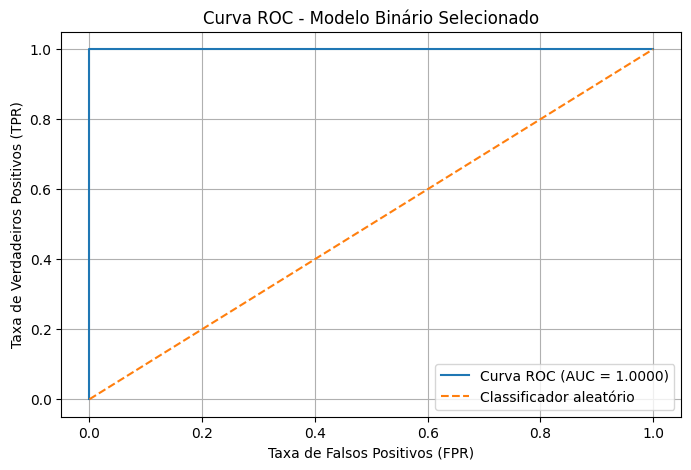

In [82]:
# @title
# =========================================================
# Curva ROC do melhor modelo binário
# =========================================================
fpr, tpr, thresholds = roc_curve(yb_test, yb_proba_conv1d_bilstm)
roc_auc_value = auc(fpr, tpr)

print("AUC calculada a partir da curva ROC:", round(roc_auc_value, 6))

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Classificador aleatório")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC - Modelo Binário Selecionado")
plt.legend()
plt.grid(True)
plt.show()

### 19. Aplicação do melhor modelo binário sobre os parâmetros extraídos dos logs



In [83]:
# @title
# =========================================================
# 1) Localiza o melhor modelo binário a partir do comparativo
# =========================================================
comparison_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-comparativo_modelos_binarios.csv"

if not comparison_path.exists():
    raise FileNotFoundError(f"Comparativo não encontrado: {comparison_path}")

df_compare_bin = pd.read_csv(comparison_path)

if df_compare_bin.empty:
    raise ValueError("O comparativo dos modelos binários está vazio.")

best_row = df_compare_bin.iloc[0]
best_experiment_prefix = best_row["experiment_prefix"]
best_model_name = best_row["model_name"]
best_model_arch = best_row["architecture"]

best_model_path = EXPERIMENTS_DIR / f"{best_experiment_prefix}.keras"

if not best_model_path.exists():
    raise FileNotFoundError(f"Modelo não encontrado: {best_model_path}")

print("Melhor modelo binário selecionado:")
print("experiment_prefix:", best_experiment_prefix)
print("model_name:", best_model_name)
print("architecture:", best_model_arch)
print("model_path:", best_model_path)

# =========================================================
# 2) Carrega o melhor modelo salvo
# =========================================================
best_bin_model = load_model(best_model_path)

# =========================================================
# 3) Prepara df_params para inferência
# =========================================================
df_params_pred = df_params.copy()

df_params_pred["texto_modelo"] = (
    df_params_pred["param_value_decoded"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

# remove vazios apenas para a inferência real
df_params_infer = df_params_pred[df_params_pred["texto_modelo"] != ""].copy()

print("\nShape original df_params:", df_params.shape)
print("Shape para inferência:", df_params_infer.shape)

# =========================================================
# 4) Predição em lote
# =========================================================
BATCH_PRED = 64

ds_params_pred = tf.data.Dataset.from_tensor_slices(
    tf.constant(df_params_infer["texto_modelo"].values)
).batch(BATCH_PRED).prefetch(tf.data.AUTOTUNE)

proba_sqli = best_bin_model.predict(ds_params_pred, verbose=0).ravel()

df_params_infer["proba_sqli"] = proba_sqli
df_params_infer["pred_sqli_binario"] = (df_params_infer["proba_sqli"] >= 0.5).astype(int)
df_params_infer["classe_prevista"] = df_params_infer["pred_sqli_binario"].map({
    0: "Nao_SQLi",
    1: "SQLi"
})

# faixas de risco auxiliares
df_params_infer["faixa_risco"] = pd.cut(
    df_params_infer["proba_sqli"],
    bins=[-0.01, 0.20, 0.50, 0.80, 1.00],
    labels=["Muito_baixo", "Baixo", "Moderado", "Alto"]
)

# =========================================================
# 5) Consolida com linhas vazias, se existirem
# =========================================================
df_params_resultado = df_params_pred.merge(
    df_params_infer[
        [
            "log_id",
            "param_position",
            "param_name_raw",
            "param_value_decoded",
            "texto_modelo",
            "proba_sqli",
            "pred_sqli_binario",
            "classe_prevista",
            "faixa_risco"
        ]
    ],
    how="left",
    on=["log_id", "param_position", "param_name_raw", "param_value_decoded", "texto_modelo"]
)

df_params_resultado["proba_sqli"] = df_params_resultado["proba_sqli"].fillna(0.0)
df_params_resultado["pred_sqli_binario"] = df_params_resultado["pred_sqli_binario"].fillna(0).astype(int)
df_params_resultado["classe_prevista"] = df_params_resultado["classe_prevista"].fillna("Nao_SQLi")
df_params_resultado["faixa_risco"] = df_params_resultado["faixa_risco"].astype("object").fillna("Muito_baixo")

# =========================================================
# 6) Recortes analíticos
# =========================================================
df_alertas_sqli = (
    df_params_resultado[df_params_resultado["pred_sqli_binario"] == 1]
    .sort_values(by="proba_sqli", ascending=False)
    .reset_index(drop=True)
)

top_20_alertas = df_alertas_sqli.head(20).copy()

# =========================================================
# 7) Salvamento padronizado
# =========================================================
saida_full_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-aplicacao_binaria_df_params.csv"
saida_alertas_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-alertas_binarios_df_params.csv"
saida_top20_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-top20_alertas_binarios_df_params.csv"

df_params_resultado.to_csv(saida_full_path, index=False)
df_alertas_sqli.to_csv(saida_alertas_path, index=False)
top_20_alertas.to_csv(saida_top20_path, index=False)

# =========================================================
# 8) Resumo final
# =========================================================
print("\n=== Resumo da aplicação do modelo binário ===")
print("Total de parâmetros avaliados:", len(df_params_resultado))
print("Total classificados como SQLi:", int(df_params_resultado["pred_sqli_binario"].sum()))
print("Total classificados como Nao_SQLi:", int((df_params_resultado["pred_sqli_binario"] == 0).sum()))

print("\nDistribuição por classe prevista:")
display(df_params_resultado["classe_prevista"].value_counts().to_frame("qtd"))

print("\nDistribuição por faixa de risco:")
display(df_params_resultado["faixa_risco"].value_counts(dropna=False).to_frame("qtd"))

print("\nTop 20 alertas com maior probabilidade de SQLi:")
colunas_top = [
    "log_id",
    "param_position",
    "param_name_raw",
    "param_value_decoded",
    "proba_sqli",
    "classe_prevista",
    "faixa_risco"
]
display(top_20_alertas[colunas_top])

print("\nArquivos salvos:")
print("-", saida_full_path)
print("-", saida_alertas_path)
print("-", saida_top20_path)

Melhor modelo binário selecionado:
experiment_prefix: 12-04-2026-conv1d_bilstm_binario
model_name: conv1d_bilstm_binario
architecture: Embedding + Conv1D + MaxPooling1D + BiLSTM + Dense
model_path: /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-conv1d_bilstm_binario.keras

Shape original df_params: (3627, 19)
Shape para inferência: (3627, 20)

=== Resumo da aplicação do modelo binário ===
Total de parâmetros avaliados: 3627
Total classificados como SQLi: 1083
Total classificados como Nao_SQLi: 2544

Distribuição por classe prevista:


,qtd
classe_prevista,
Nao_SQLi,2544
SQLi,1083



Distribuição por faixa de risco:


,qtd
faixa_risco,
Muito_baixo,2544
Alto,1083



Top 20 alertas com maior probabilidade de SQLi:


,log_id,param_position,param_name_raw,param_value_decoded,proba_sqli,classe_prevista,faixa_risco
0,479,1,q,( Case wHEN 7019 lIKE 2802 ...,0.999987,SQLi,Alto
1,475,1,q,( cASe WhEN (1482 LiKe 4555) ...,0.999987,SQLi,Alto
2,480,1,q,( CAse whEN 5520 liKe 5520 tH...,0.999985,SQLi,Alto
3,481,1,q,( caSE When 5877 lIKe 8783 THeN...,0.999985,SQLi,Alto
4,478,1,q,( CasE wHen (5005 LIkE 5005) ...,0.999985,SQLi,Alto
5,482,1,q,( cAsE wheN 1386 LikE 1386 tHEN ...,0.999983,SQLi,Alto
6,477,1,q,( caSe WheN (8033 lIke 9301) The...,0.999982,SQLi,Alto
7,476,1,q,( cASE wHeN (7697 LiKe 7697) THE...,0.999982,SQLi,Alto
8,557,1,q,"( SelecT cONCAt( cONCAt( cHar(113,1...",0.999981,SQLi,Alto
9,474,1,q,( SelEcT ( CaSE WHen (5699 ...,0.999981,SQLi,Alto



Arquivos salvos:
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-aplicacao_binaria_df_params.csv
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-alertas_binarios_df_params.csv
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-top20_alertas_binarios_df_params.csv


### 20. Consolidação dos alertas por requisição

In [84]:
# @title
# =========================================================
# 1) Consolidação por log_id
# =========================================================
df_logs_resumo = (
    df_params_resultado
    .groupby("log_id", as_index=False)
    .agg(
        total_parametros=("param_position", "count"),
        total_parametros_sqli=("pred_sqli_binario", "sum"),
        maior_proba_sqli=("proba_sqli", "max"),
        media_proba_sqli=("proba_sqli", "mean"),
        url_path=("url_path", "first"),
        http_method=("http_method", "first"),
        query_string=("query_string", "first"),
        status=("status", "first"),
        request_time=("request_time", "first")
    )
)

df_logs_resumo["teve_alerta_sqli"] = (df_logs_resumo["total_parametros_sqli"] > 0).astype(int)
df_logs_resumo["classe_log"] = df_logs_resumo["teve_alerta_sqli"].map({
    0: "Nao_SQLi",
    1: "SQLi"
})

df_logs_resumo["faixa_risco_log"] = pd.cut(
    df_logs_resumo["maior_proba_sqli"],
    bins=[-0.01, 0.20, 0.50, 0.80, 1.00],
    labels=["Muito_baixo", "Baixo", "Moderado", "Alto"]
)

df_logs_alertas = (
    df_logs_resumo[df_logs_resumo["teve_alerta_sqli"] == 1]
    .sort_values(
        by=["maior_proba_sqli", "total_parametros_sqli"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

top_20_logs_alerta = df_logs_alertas.head(20).copy()

# =========================================================
# 2) Salvamento
# =========================================================
logs_resumo_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-resumo_por_log.csv"
logs_alertas_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-alertas_por_log.csv"
logs_top20_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-top20_alertas_por_log.csv"

df_logs_resumo.to_csv(logs_resumo_path, index=False)
df_logs_alertas.to_csv(logs_alertas_path, index=False)
top_20_logs_alerta.to_csv(logs_top20_path, index=False)

# =========================================================
# 3) Resumo
# =========================================================
print("=== Resumo por requisição ===")
print("Total de logs avaliados:", len(df_logs_resumo))
print("Logs com alerta SQLi:", int(df_logs_resumo["teve_alerta_sqli"].sum()))
print("Logs sem alerta SQLi:", int((df_logs_resumo["teve_alerta_sqli"] == 0).sum()))

print("\nDistribuição por classe do log:")
display(df_logs_resumo["classe_log"].value_counts().to_frame("qtd"))

print("\nDistribuição por faixa de risco do log:")
display(df_logs_resumo["faixa_risco_log"].value_counts(dropna=False).to_frame("qtd"))

print("\nTop 20 logs com maior risco:")
display(
    top_20_logs_alerta[
        [
            "log_id",
            "http_method",
            "url_path",
            "status",
            "total_parametros",
            "total_parametros_sqli",
            "maior_proba_sqli",
            "media_proba_sqli",
            "faixa_risco_log"
        ]
    ]
)

print("\nArquivos salvos:")
print("-", logs_resumo_path)
print("-", logs_alertas_path)
print("-", logs_top20_path)

=== Resumo por requisição ===
Total de logs avaliados: 3626
Logs com alerta SQLi: 1083
Logs sem alerta SQLi: 2543

Distribuição por classe do log:


,qtd
classe_log,
Nao_SQLi,2543
SQLi,1083



Distribuição por faixa de risco do log:


,qtd
faixa_risco_log,
Muito_baixo,2543
Alto,1083
Baixo,0
Moderado,0



Top 20 logs com maior risco:


,log_id,http_method,url_path,status,total_parametros,total_parametros_sqli,maior_proba_sqli,media_proba_sqli,faixa_risco_log
0,479,GET,/rest/products/search,200,1,1,0.999987,0.999987,Alto
1,475,GET,/rest/products/search,200,1,1,0.999987,0.999987,Alto
2,480,GET,/rest/products/search,200,1,1,0.999985,0.999985,Alto
3,481,GET,/rest/products/search,200,1,1,0.999985,0.999985,Alto
4,478,GET,/rest/products/search,200,1,1,0.999985,0.999985,Alto
5,482,GET,/rest/products/search,200,1,1,0.999983,0.999983,Alto
6,477,GET,/rest/products/search,200,1,1,0.999982,0.999982,Alto
7,476,GET,/rest/products/search,200,1,1,0.999982,0.999982,Alto
8,474,GET,/rest/products/search,200,1,1,0.999981,0.999981,Alto
9,557,GET,/rest/products/search,200,1,1,0.999981,0.999981,Alto



Arquivos salvos:
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-resumo_por_log.csv
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-alertas_por_log.csv
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-top20_alertas_por_log.csv


### 21. Análise consolidada dos alertas por endpoint e método HTTP

In [85]:
# @title
# =========================================================
# 1) Resumo por endpoint e método
# =========================================================
df_endpoint_resumo = (
    df_logs_resumo
    .groupby(["http_method", "url_path"], as_index=False)
    .agg(
        total_logs=("log_id", "count"),
        logs_com_alerta=("teve_alerta_sqli", "sum"),
        maior_proba_sqli=("maior_proba_sqli", "max"),
        media_proba_sqli=("media_proba_sqli", "mean"),
        media_parametros_sqli=("total_parametros_sqli", "mean")
    )
)

df_endpoint_resumo["perc_logs_com_alerta"] = (
    df_endpoint_resumo["logs_com_alerta"] / df_endpoint_resumo["total_logs"]
)

df_endpoint_resumo = df_endpoint_resumo.sort_values(
    by=["logs_com_alerta", "maior_proba_sqli", "perc_logs_com_alerta"],
    ascending=[False, False, False]
).reset_index(drop=True)

top_20_endpoints = df_endpoint_resumo.head(20).copy()

# =========================================================
# 2) Resumo adicional por status
# =========================================================
df_status_resumo = (
    df_logs_resumo
    .groupby("status", as_index=False)
    .agg(
        total_logs=("log_id", "count"),
        logs_com_alerta=("teve_alerta_sqli", "sum"),
        maior_proba_sqli=("maior_proba_sqli", "max"),
        media_proba_sqli=("media_proba_sqli", "mean")
    )
)

df_status_resumo["perc_logs_com_alerta"] = (
    df_status_resumo["logs_com_alerta"] / df_status_resumo["total_logs"]
)

df_status_resumo = df_status_resumo.sort_values(
    by=["logs_com_alerta", "perc_logs_com_alerta"],
    ascending=[False, False]
).reset_index(drop=True)

# =========================================================
# 3) Salvamento
# =========================================================
endpoint_resumo_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-resumo_por_endpoint.csv"
status_resumo_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-resumo_por_status.csv"
endpoint_top20_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-top20_endpoints_alerta.csv"

df_endpoint_resumo.to_csv(endpoint_resumo_path, index=False)
df_status_resumo.to_csv(status_resumo_path, index=False)
top_20_endpoints.to_csv(endpoint_top20_path, index=False)

# =========================================================
# 4) Saída
# =========================================================
print("=== Resumo por endpoint ===")
print("Total de combinações método + endpoint:", len(df_endpoint_resumo))

print("\nTop 20 endpoints com mais alertas:")
display(top_20_endpoints)

print("\nResumo por status HTTP:")
display(df_status_resumo)

print("\nArquivos salvos:")
print("-", endpoint_resumo_path)
print("-", status_resumo_path)
print("-", endpoint_top20_path)

=== Resumo por endpoint ===
Total de combinações método + endpoint: 2

Top 20 endpoints com mais alertas:


,http_method,url_path,total_logs,logs_com_alerta,maior_proba_sqli,media_proba_sqli,media_parametros_sqli,perc_logs_com_alerta
0,GET,/rest/products/search,3625,1082,0.999987,0.298450,0.298483,0.298483
1,POST,/rest/user/login,1,1,0.999962,0.999962,1.000000,1.000000



Resumo por status HTTP:


,status,total_logs,logs_com_alerta,maior_proba_sqli,media_proba_sqli,perc_logs_com_alerta
0,200,3625,1082,0.999987,0.298450,0.298483
1,401,1,1,0.999962,0.999962,1.000000



Arquivos salvos:
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-resumo_por_endpoint.csv
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-resumo_por_status.csv
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-top20_endpoints_alerta.csv


### 22. Síntese executiva dos resultados do case

In [99]:
# =========================================================
# 1) KPIs principais
# =========================================================
total_logs = int(len(df_logs_resumo))
logs_com_alerta = int(df_logs_resumo["teve_alerta_sqli"].sum())
logs_sem_alerta = int((df_logs_resumo["teve_alerta_sqli"] == 0).sum())
perc_logs_alerta = logs_com_alerta / total_logs if total_logs > 0 else 0

total_params = int(len(df_params_resultado))
params_sqli = int(df_params_resultado["pred_sqli_binario"].sum())
params_nao_sqli = int((df_params_resultado["pred_sqli_binario"] == 0).sum())
perc_params_sqli = params_sqli / total_params if total_params > 0 else 0

top_endpoint = df_endpoint_resumo.iloc[0].to_dict()
top_status = df_status_resumo.iloc[0].to_dict()

# =========================================================
# 2) Tabela executiva
# =========================================================
df_exec_summary = pd.DataFrame([
    {"indicador": "Modelo selecionado", "valor": best_model_name},
    {"indicador": "Arquitetura selecionada", "valor": best_model_arch},
    {"indicador": "Total de logs avaliados", "valor": total_logs},
    {"indicador": "Logs com alerta SQLi", "valor": logs_com_alerta},
    {"indicador": "Logs sem alerta SQLi", "valor": logs_sem_alerta},
    {"indicador": "% de logs com alerta", "valor": round(perc_logs_alerta * 100, 2)},
    {"indicador": "Total de parâmetros avaliados", "valor": total_params},
    {"indicador": "Parâmetros classificados como SQLi", "valor": params_sqli},
    {"indicador": "Parâmetros classificados como Nao_SQLi", "valor": params_nao_sqli},
    {"indicador": "% de parâmetros classificados como SQLi", "valor": round(perc_params_sqli * 100, 2)},
    {"indicador": "Endpoint com mais alertas", "valor": f"{top_endpoint['http_method']} {top_endpoint['url_path']}"},
    {"indicador": "Logs com alerta no principal endpoint", "valor": int(top_endpoint["logs_com_alerta"])},
    {"indicador": "Maior probabilidade no principal endpoint", "valor": round(float(top_endpoint["maior_proba_sqli"]), 6)},
    {"indicador": "Status HTTP com mais alertas", "valor": int(top_status["status"])},
    {"indicador": "Logs com alerta no principal status", "valor": int(top_status["logs_com_alerta"])},
])

exec_summary_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-resumo_executivo_case.csv"
df_exec_summary.to_csv(exec_summary_path, index=False)

# =========================================================
# 3) Texto executivo automático
# =========================================================
texto_executivo = f"""

O melhor modelo selecionado foi '{best_model_name}', baseado na arquitetura '{best_model_arch}'.
Na aplicação sobre os parâmetros extraídos dos logs, foram avaliados {total_params} parâmetros,
dos quais {params_sqli} ({perc_params_sqli * 100:.2f}%) foram classificados como SQLi.

Na consolidação por requisição, foram avaliados {total_logs} logs, dos quais
{logs_com_alerta} ({perc_logs_alerta * 100:.2f}%) apresentaram pelo menos um alerta de SQL Injection.

O endpoint com maior concentração de alertas foi '{top_endpoint['http_method']} {top_endpoint['url_path']}',
com {int(top_endpoint['logs_com_alerta'])} logs sinalizados. O status HTTP mais associado aos alertas foi
{int(top_status['status'])}, com {int(top_status['logs_com_alerta'])} ocorrências.

Os resultados indicam boa capacidade de detecção binária no contexto da base atual. Entretanto,
a forte concentração dos eventos em poucos endpoints e a necessidade de ampliar a diversidade de logs
benignos e maliciosos sugerem que novas coletas devem ser realizadas para fortalecer a generalização do modelo.
""".strip()

texto_exec_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-resumo_executivo_case.txt"
with open(texto_exec_path, "w", encoding="utf-8") as f:
    f.write(texto_executivo)

# =========================================================
# 4) Saída
# =========================================================
print("=== Tabela executiva ===")
display(df_exec_summary)

print("\n")
print("=== Resumo executivo do case LogsSQLi ===")
print("\n" + texto_executivo)
print("\nArquivos salvos:")
print("-", exec_summary_path)
print("-", texto_exec_path)

=== Tabela técnica ===


,indicador,valor
0,Modelo selecionado,conv1d_bilstm_binario
1,Arquitetura selecionada,Embedding + Conv1D + MaxPooling1D + BiLSTM + D...
2,Total de logs avaliados,3626
3,Logs com alerta SQLi,1083
4,Logs sem alerta SQLi,2543
5,% de logs com alerta,29.87
6,Total de parâmetros avaliados,3627
7,Parâmetros classificados como SQLi,1083
8,Parâmetros classificados como Nao_SQLi,2544
9,% de parâmetros classificados como SQLi,29.86




=== Resumo executivo do case LogsSQLi ===

O melhor modelo selecionado foi 'conv1d_bilstm_binario', baseado na arquitetura 'Embedding + Conv1D + MaxPooling1D + BiLSTM + Dense'.
Na aplicação sobre os parâmetros extraídos dos logs, foram avaliados 3627 parâmetros,
dos quais 1083 (29.86%) foram classificados como SQLi.

Na consolidação por requisição, foram avaliados 3626 logs, dos quais
1083 (29.87%) apresentaram pelo menos um alerta de SQL Injection.

O endpoint com maior concentração de alertas foi 'GET /rest/products/search',
com 1082 logs sinalizados. O status HTTP mais associado aos alertas foi
200, com 1082 ocorrências.

Os resultados indicam boa capacidade de detecção binária no contexto da base atual. Entretanto,
a forte concentração dos eventos em poucos endpoints e a necessidade de ampliar a diversidade de logs
benignos e maliciosos sugerem que novas coletas devem ser realizadas para fortalecer a generalização do modelo.

Arquivos salvos:
- /content/drive/MyDrive/LogsSQLi/dat

### 23. Escopo final do notebook e estratégia de evolução

In [87]:
escopo_final = {
    "objetivo_principal": "Deteccao binaria de SQL Injection",
    "classes_saida": ["SQLi", "Nao_SQLi"],
    "modelo_selecionado": best_model_name,
    "arquitetura_selecionada": best_model_arch,
    "vetorizacao": "caractere",
    "entrega_multirrotulo": "exploratoria_nao_utilizada_como_resultado_final",
    "estrutura_notebook_mantida_para_futuras_bases": True,
    "blocos_que_tendem_a_permanecer_estaveis": [
        "carregamento_das_bases",
        "vetorizacao_textual",
        "criacao_dos_datasets_tfdata",
        "treinamento_dos_modelos_binarios",
        "aplicacao_do_melhor_modelo_em_df_params",
        "consolidacao_por_log_endpoint_e_status"
    ],
    "blocos_com_maior_probabilidade_de_ajuste_futuro": [
        "construcao_da_classe_negativa",
        "criterios_de_balanceamento",
        "threshold_de_decisao",
        "eventual_retomada_da_classificacao_por_tipo"
    ]
}

escopo_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-escopo_final_notebook.json"

with open(escopo_path, "w", encoding="utf-8") as f:
    json.dump(escopo_final, f, ensure_ascii=False, indent=2)

print("=== Escopo final do notebook ===")
for chave, valor in escopo_final.items():
    print(f"{chave}: {valor}")

print("\nArquivo salvo:")
print("-", escopo_path)

=== Escopo final do notebook ===
objetivo_principal: Deteccao binaria de SQL Injection
classes_saida: ['SQLi', 'Nao_SQLi']
modelo_selecionado: conv1d_bilstm_binario
arquitetura_selecionada: Embedding + Conv1D + MaxPooling1D + BiLSTM + Dense
vetorizacao: caractere
entrega_multirrotulo: exploratoria_nao_utilizada_como_resultado_final
estrutura_notebook_mantida_para_futuras_bases: True
blocos_que_tendem_a_permanecer_estaveis: ['carregamento_das_bases', 'vetorizacao_textual', 'criacao_dos_datasets_tfdata', 'treinamento_dos_modelos_binarios', 'aplicacao_do_melhor_modelo_em_df_params', 'consolidacao_por_log_endpoint_e_status']
blocos_com_maior_probabilidade_de_ajuste_futuro: ['construcao_da_classe_negativa', 'criterios_de_balanceamento', 'threshold_de_decisao', 'eventual_retomada_da_classificacao_por_tipo']

Arquivo salvo:
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-escopo_final_notebook.json


### 24. Inventário final dos artefatos gerados

In [101]:
arquivos_experimentos = sorted(EXPERIMENTS_DIR.glob("*"))

registros = []
for p in arquivos_experimentos:
    registros.append({
        "arquivo": p.name,
        "extensao": p.suffix if p.suffix else "(sem_extensao)",
        "tipo_inferido": (
            "modelo" if p.suffix == ".keras" else
            "csv" if p.suffix == ".csv" else
            "json" if p.suffix == ".json" else
            "texto" if p.suffix == ".txt" else
            "outro"
        ),
        "caminho": str(p)
    })

df_inventario_artefatos = pd.DataFrame(registros)

inventario_path = EXPERIMENTS_DIR / f"{EXPERIMENT_DATE}-inventario_artefatos_ml.csv"
df_inventario_artefatos.to_csv(inventario_path, index=False)

print("=== Inventário final de artefatos ===")
print("Quantidade total de arquivos:", len(df_inventario_artefatos))

print("\nResumo por tipo:")
display(df_inventario_artefatos["tipo_inferido"].value_counts().to_frame("qtd"))

print("\nAmostra do inventário:")
display(df_inventario_artefatos.head(30))

print("\nArquivo salvo:")
print("-", inventario_path)

=== Inventário final de artefatos ===
Quantidade total de arquivos: 50

Resumo por tipo:


,qtd
tipo_inferido,
csv,38
json,6
modelo,5
texto,1



Amostra do inventário:


,arquivo,extensao,tipo_inferido,caminho
0,12-04-2026-alertas_binarios_df_params.csv,.csv,csv,/content/drive/MyDrive/LogsSQLi/data/processed...
1,12-04-2026-alertas_por_log.csv,.csv,csv,/content/drive/MyDrive/LogsSQLi/data/processed...
2,12-04-2026-aplicacao_binaria_df_params.csv,.csv,csv,/content/drive/MyDrive/LogsSQLi/data/processed...
3,12-04-2026-base_robustez_modelo_campeao.csv,.csv,csv,/content/drive/MyDrive/LogsSQLi/data/processed...
4,12-04-2026-baseline_binario-classification-rep...,.csv,csv,/content/drive/MyDrive/LogsSQLi/data/processed...
5,12-04-2026-baseline_binario-confusion-matrix.csv,.csv,csv,/content/drive/MyDrive/LogsSQLi/data/processed...
6,12-04-2026-baseline_binario-history.csv,.csv,csv,/content/drive/MyDrive/LogsSQLi/data/processed...
7,12-04-2026-baseline_binario-metadata.json,.json,json,/content/drive/MyDrive/LogsSQLi/data/processed...
8,12-04-2026-baseline_binario-metrics-test.csv,.csv,csv,/content/drive/MyDrive/LogsSQLi/data/processed...
9,12-04-2026-baseline_binario-predictions-test.csv,.csv,csv,/content/drive/MyDrive/LogsSQLi/data/processed...



Arquivo salvo:
- /content/drive/MyDrive/LogsSQLi/data/processed/ml/experiments/12-04-2026-inventario_artefatos_ml.csv


### 25. Encaminhamento para as próximas fases

Com base nos resultados obtidos nesta etapa, a continuidade do projeto deverá priorizar o fortalecimento da base de dados e a ampliação da cobertura dos cenários monitorados.

A próxima evolução recomendada consiste em expandir a dimensão de payloads de SQL Injection com novos exemplos rotulados, além de enriquecer os logs com maior diversidade de tráfego benigno e malicioso. Entre os eventos benignos, destacam-se autenticações bem-sucedidas, falhas de login legítimas, buscas simples, filtros usuais, parâmetros de paginação, ordenação e navegação. Entre os eventos maliciosos, recomenda-se incluir novas variações de SQL Injection com diferentes níveis de obfuscação, codificação e combinação de operadores.

A estrutura construída neste notebook permite que futuras versões reaproveitem a maior parte do pipeline atual. As adaptações mais prováveis deverão ocorrer na construção da classe negativa, no balanceamento entre as classes, na calibração do limiar de decisão e na eventual retomada da classificação dos tipos de SQL Injection, caso a nova base apresente volume e diversidade suficientes para sustentar essa tarefa com maior confiabilidade.

Assim, a etapa atual entrega uma solução funcional para detecção binária de SQL Injection e estabelece uma base metodológica sólida para ciclos futuros de refinamento, revalidação e expansão analítica.

### 26. Dicionário de dados da base analítica e das tabelas auxiliares

### Dicionário de dados

| Variável | Tipo | Origem | Descrição |
|---|---|---|---|
| `payload_match_key` | Categórica textual | `df_payload_train` | Texto padronizado do payload utilizado como entrada principal no treinamento supervisionado. |
| `payload_example` | Categórica textual | `df_payload_train` | Exemplo representativo do payload original associado à chave padronizada. |
| `qtd_payloads_origem` | Numérica discreta | `df_payload_train` | Quantidade de payloads originais consolidados na mesma chave padronizada. |
| `qtd_tipos_distintos` | Numérica discreta | `df_payload_train` | Quantidade de categorias distintas de SQL Injection associadas ao payload. |
| `tipos_encontrados` | Categórica textual estruturada | `df_payload_train` | Lista textual dos tipos de SQL Injection associados ao payload. |
| `tipo_match_exato` | Categórica textual | `df_payload_train` | Tipo principal ou consolidado associado ao payload padronizado. |
| `tipos_lista` | Categórica textual estruturada | `df_payload_train` | Lista processada dos tipos associados à amostra após tratamento. |
| `target_sqli_binario` | Numérica binária | `df_payload_train` / `df_train_bin` | Indicador binário da presença de SQL Injection, em que `1` representa SQLi e `0` representa entrada benigna. |
| `texto_entrada` | Categórica textual | `df_payload_train` / `df_train_bin` | Texto efetivamente utilizado como entrada dos modelos neurais. |
| `tipos_alvo` | Categórica textual | `df_payload_train` / `df_train_bin` | Representação textual consolidada dos tipos associados à amostra, ou `Benign` na classe negativa. |
| `texto_len` | Numérica discreta | `df_payload_train` | Comprimento do texto de entrada em caracteres. |
| `origem` | Categórica textual | `df_train_bin` | Origem da amostra na construção da base binária, indicando se veio da dimensão de payloads ou da classe negativa controlada. |
| `log_id` | Numérica discreta | `df_params_resultado` / `df_logs_resumo` | Identificador único da requisição no conjunto de logs analisado. |
| `time_local` | Data/hora textual | `df_params_resultado` | Timestamp original da requisição conforme registrado no log. |
| `status` | Numérica discreta | `df_params_resultado` / `df_logs_resumo` / `df_status_resumo` | Código de status HTTP retornado pela aplicação. |
| `request_success` | Numérica binária | `df_params_resultado` | Indicador simplificado de sucesso da requisição. |
| `request_time` | Numérica contínua | `df_params_resultado` / `df_logs_resumo` | Tempo de resposta da requisição. |
| `body_bytes_sent` | Numérica contínua | `df_params_resultado` | Quantidade de bytes enviados na resposta HTTP. |
| `http_method` | Categórica textual | `df_params_resultado` / `df_logs_resumo` / `df_endpoint_resumo` | Método HTTP utilizado na requisição, como `GET` ou `POST`. |
| `url_path` | Categórica textual | `df_params_resultado` / `df_logs_resumo` / `df_endpoint_resumo` | Caminho do endpoint acessado na aplicação. |
| `query_string` | Categórica textual | `df_params_resultado` / `df_logs_resumo` | Query string completa extraída da URL da requisição. |
| `param_position` | Numérica discreta | `df_params_resultado` | Posição do parâmetro dentro da query string expandida. |
| `param_raw` | Categórica textual | `df_params_resultado` | Representação bruta do parâmetro no formato original extraído da query string. |
| `param_name_raw` | Categórica textual | `df_params_resultado` | Nome bruto do parâmetro analisado. |
| `param_value_raw` | Categórica textual | `df_params_resultado` | Valor bruto do parâmetro antes de decodificação. |
| `has_equals_sign` | Numérica binária | `df_params_resultado` | Indicador de presença do caractere `=` no parâmetro expandido. |
| `param_value_decoded` | Categórica textual | `df_params_resultado` | Valor do parâmetro após decodificação e normalização textual. |
| `param_value_match_key` | Categórica textual | `df_params_resultado` | Chave textual padronizada do valor do parâmetro. |
| `param_value_raw_length` | Numérica discreta | `df_params_resultado` | Comprimento do valor bruto do parâmetro em caracteres. |
| `param_value_decoded_length` | Numérica discreta | `df_params_resultado` | Comprimento do valor decodificado do parâmetro em caracteres. |
| `param_value_was_changed` | Numérica binária | `df_params_resultado` | Indicador de alteração entre o valor bruto e o valor decodificado. |
| `texto_modelo` | Categórica textual | `df_params_resultado` | Texto preparado e normalizado especificamente para entrada no modelo binário. |
| `proba_sqli` | Numérica contínua | `df_params_resultado` / `df_logs_resumo` / `df_endpoint_resumo` / `df_status_resumo` | Probabilidade prevista pelo modelo para a classe SQLi. Em tabelas agregadas, representa máximo ou média conforme o nível de consolidação. |
| `pred_sqli_binario` | Numérica binária | `df_params_resultado` | Predição binária final do modelo em nível de parâmetro, em que `1` indica SQLi. |
| `classe_prevista` | Categórica textual | `df_params_resultado` | Classe textual prevista pelo modelo, `SQLi` ou `Nao_SQLi`. |
| `faixa_risco` | Categórica ordinal | `df_params_resultado` | Faixa qualitativa de risco derivada da probabilidade prevista para o parâmetro. |
| `total_parametros` | Numérica discreta | `df_logs_resumo` | Quantidade total de parâmetros analisados em cada requisição. |
| `total_parametros_sqli` | Numérica discreta | `df_logs_resumo` | Quantidade de parâmetros classificados como SQLi dentro da mesma requisição. |
| `maior_proba_sqli` | Numérica contínua | `df_logs_resumo` / `df_endpoint_resumo` / `df_status_resumo` | Maior probabilidade de SQLi observada no agrupamento analisado. |
| `media_proba_sqli` | Numérica contínua | `df_logs_resumo` / `df_endpoint_resumo` / `df_status_resumo` | Média das probabilidades de SQLi observadas no agrupamento analisado. |
| `teve_alerta_sqli` | Numérica binária | `df_logs_resumo` | Indicador de que a requisição apresentou pelo menos um parâmetro classificado como SQLi. |
| `classe_log` | Categórica textual | `df_logs_resumo` | Classe consolidada da requisição, `SQLi` ou `Nao_SQLi`, com base na presença de alertas nos parâmetros. |
| `faixa_risco_log` | Categórica ordinal | `df_logs_resumo` | Faixa qualitativa de risco atribuída à requisição com base na maior probabilidade observada. |
| `total_logs` | Numérica discreta | `df_endpoint_resumo` / `df_status_resumo` | Quantidade total de requisições observadas no agrupamento por endpoint ou por status HTTP. |
| `logs_com_alerta` | Numérica discreta | `df_endpoint_resumo` / `df_status_resumo` | Quantidade de requisições com pelo menos um alerta SQLi no agrupamento analisado. |
| `media_parametros_sqli` | Numérica contínua | `df_endpoint_resumo` | Média de parâmetros suspeitos por requisição no endpoint consolidado. |
| `perc_logs_com_alerta` | Numérica contínua | `df_endpoint_resumo` / `df_status_resumo` | Proporção de requisições com alerta SQLi no agrupamento analisado. |
| `indicador` | Categórica textual | `df_exec_summary` | Nome do indicador executivo consolidado para apresentação final dos resultados. |
| `valor` | Categórica textual / numérica | `df_exec_summary` | Valor associado ao indicador executivo consolidado. |

### 27. Conclusão sobre teste de robustez e hiperparâmetros

Os testes realizados com diferentes arquiteturas neurais indicaram que a tarefa de **detecção binária de SQL Injection** apresentou desempenho muito elevado na base atualmente disponível. Os modelos `Embedding + BiLSTM + Dense`, `Embedding + Conv1D + GlobalMaxPooling1D + Dense` e `Embedding + Conv1D + MaxPooling1D + BiLSTM + Dense` atingiram resultados máximos nas métricas de teste, o que demonstra forte capacidade de separação entre exemplos classificados como `SQLi` e `Nao_SQLi` dentro do contexto observado neste projeto.

Entretanto, a análise de robustez mostra que esse desempenho deve ser interpretado com cautela. A base utilizada ainda apresenta limitações importantes, como concentração excessiva de eventos em poucas rotas, baixa diversidade de tráfego benigno real e construção da classe negativa a partir de poucos exemplos benignos originais. Assim, embora os resultados sejam consistentes para a base atual, eles não devem ser entendidos como evidência definitiva de generalização ampla sem a ampliação futura dos dados de treinamento e teste.

No que se refere aos hiperparâmetros, a configuração adotada mostrou-se adequada para o cenário estudado. A vetorização em nível de caractere foi uma escolha coerente com a natureza dos payloads e parâmetros HTTP, pois preserva operadores, aspas, comentários, símbolos especiais e padrões sintáticos frequentemente explorados em ataques de SQL Injection. O comprimento máximo das sequências foi definido em 82 caracteres, com vocabulário de 58 tokens, permitindo representar adequadamente os textos observados na base sem inflar desnecessariamente o custo computacional.

Entre as arquiteturas testadas, o modelo selecionado como principal foi `Embedding + Conv1D + MaxPooling1D + BiLSTM + Dense`, por reunir extração de padrões locais e modelagem sequencial bidirecional. Seus principais hiperparâmetros foram: camada de embedding com dimensão 64, camada convolucional com 128 filtros e kernel de tamanho 5, max pooling com janela 2, camada BiLSTM com 64 unidades, camada densa com 64 neurônios e dropout de 0,30. O treinamento utilizou lote de tamanho 32, otimizador Adam com taxa de aprendizado inicial de 0,001, estratégia de redução automática da taxa de aprendizado e early stopping para controle do processo de convergência.

Por outro lado, o teste de robustez também evidenciou que a **classificação dos tipos de SQL Injection** ainda não se mostrou confiável com a base atual. Apesar de valores aparentemente altos em métricas agregadas por posição de rótulo, as métricas mais apropriadas para o problema multirrótulo, como F1 micro, F1 macro, F1 weighted e subset accuracy, indicaram ausência de capacidade preditiva efetiva sobre os tipos. Dessa forma, a decisão metodológica mais adequada foi manter a **detecção binária** como entrega principal do notebook e tratar a classificação por tipo apenas como etapa exploratória e futura.